# Business Understanding

**Potential Stakeholders**: WNBA Management, Team Executives, Sports Analysts and Commentators, Agents, Fans

**Stakeholder Actions**:
- **WNBA Management**: Use predictions to inform marketing strategies and policy decisions.
- **Team Executives**: Apply insights to guide roster moves, coaching hires, and playoff preparation.
- **Sports Analysts and Commentators**: Leverage forecasts to enrich game coverage and provide deeper analysis to audiences.
- **Agents**: Identify emerging talent and award contenders for targeted representation and contract negotiations.
- **Fans**: Engage with predictive content to enhance season experience and participate in discussions around team and player performance.

**Available Data**: 10 years of comprehensive WNBA data including player statistics, team performance, coaching records, and awards history. The predictions for the test season will be made as if it were the day before the season begins, therefore only data from past years can be used. The main risks involve missing values, data inconsistencies, limited sample size, potential class imbalance and integrating the datasets, all of which may affect model accuracy and reliability.

**Business Objectives**:
1. **Improve Team Performance Prediction**: Develop models to accurately predict conference rankings
   - Success Metric: Correctly rank teams within ±2 positions of actual final standings
   - Business Value: Enables better strategic planning for playoffs and roster management

2. **Optimize Coaching Decisions**: Predict which teams are likely to change coaches
   - Success Metric: Identify 70%+ of teams that will undergo coaching changes
   - Business Value: Reduces costs of poor coaching fits and improves team stability

3. **Identify Award Winners Early**: Predict individual award recipients
   - Success Metric: Correctly predict 60%+ of major award winners
   - Business Value: Enhances marketing campaigns and fan engagement throughout season; allows agents and teams to identify promising players to work with

**Secondary Goals**:
- Understand key performance indicators that differentiate successful teams
- Identify player attributes that correlate with award recognition
- Analyze impact of coaching experience on team performance

## Business Goals

### Goal 1: Conference Ranking Prediction
**Data Mining Task**: Regression/Ranking Problem
- **Target Variable**: Team rank within conference
- **Features**: 
  - Team statistics: offensive/defensive efficiency, win%, home/away performance
  - Player statistics: NBA_PER, assist-to-turnover ratio, shooting percentages
  - Historical performance: previous season rankings, playoff appearances
- **Approach**: Ordinal regression or learning-to-rank algorithms
- **Evaluation Metric**: Mean Absolute Error (MAE) in ranking position, Spearman correlation

### Goal 2: Coaching Change Prediction
**Data Mining Task**: Binary Classification Problem
- **Target Variable**: Coach change (Yes/No) in upcoming season
- **Features**:
  - Team performance: win%, playoff participation, win_pct variance
  - Coach statistics: experience (seasons coached), historical win%, recent performance trend
  - Situational factors: consecutive losing seasons, missing playoffs
- **Approach**: Logistic Regression, Random Forest, XGBoost
- **Evaluation Metric**: Precision, Recall, F1-Score (class imbalance likely)

### Goal 3: Award Winner Prediction
**Data Mining Task**: Multi-class Classification Problem (per award category)
- **Target Variables**: 
  - MVP
  - Rookie of the Year
  - Defensive Player of the Year
  - Most Improved Player
- **Features**:
  - Player statistics: NBA_PER, ppg, apg, rpg, spg, bpg, True Shooting %
  - Team context: team win%, playoff success
  - Player position and role
  - Historical award patterns by position
- **Approach**: Multi-class classification (Random Forest, Neural Networks)
- **Evaluation Metric**: Top-3 Accuracy, Precision@K

## Project Plan

**Phase 1: Data Understanding & Preparation**
- Explore and assess data quality across all datasets (teams, players, coaches, awards)
- Handle missing values, outliers, and inconsistencies
- Engineer relevant features for each prediction task
- Create unified dataset with proper temporal alignment

**Phase 2: Model Development**
- Conference Ranking Prediction models
- Coaching Change Prediction models  
- Award Winner Prediction models
- Establish baseline models and iterate with parameter tuning

**Phase 3: Model Evaluation & Selection**
- Compare models against success metrics
- Perform cross-validation and temporal validation
- Select best-performing models for each task

# Data Understanding

## Setup & Data Collection

In [46]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

In [47]:
sns.set_theme(style="whitegrid", palette="pastel")
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)

In [48]:
awards_players_df = pd.read_csv('../datasets/awards_players.csv')
coaches_df        = pd.read_csv('../datasets/coaches.csv')
players_teams_df  = pd.read_csv('../datasets/players_teams.csv')
players_df        = pd.read_csv('../datasets/players.csv')
series_post_df    = pd.read_csv('../datasets/series_post.csv')
teams_post_df     = pd.read_csv('../datasets/teams_post.csv')
teams_df          = pd.read_csv('../datasets/teams.csv')

## Data Description & Quality

### *awards_players*

In [49]:
display(awards_players_df.describe(include='all'))
print("\nMissing Values per Column:")
display(awards_players_df.isnull().sum())
print(f"Number of duplicate rows: {awards_players_df.duplicated().sum()}")

,playerID,award,year,lgID
count,95,95,95.000000,95
unique,58,12,NaN,1
top,leslili01w,Coach of the Year,NaN,WNBA
freq,10,10,NaN,95
mean,NaN,NaN,5.789474,NaN
std,NaN,NaN,2.747900,NaN
min,NaN,NaN,1.000000,NaN
25%,NaN,NaN,3.500000,NaN
50%,NaN,NaN,7.000000,NaN
75%,NaN,NaN,8.000000,NaN



Missing Values per Column:


playerID    0
award       0
year        0
lgID        0
dtype: int64

Number of duplicate rows: 0


### *coaches*

In [50]:
display(coaches_df.describe(include='all'))
print("\nMissing Values per Column:")
display(coaches_df.isnull().sum())
print(f"Number of duplicate rows: {coaches_df.duplicated().sum()}")

,coachID,year,tmID,lgID,stint,won,lost,post_wins,post_losses
count,162,162.000000,162,162,162.000000,162.000000,162.000000,162.000000,162.000000
unique,57,NaN,20,1,NaN,NaN,NaN,NaN,NaN
top,donovan99w,NaN,WAS,WNBA,NaN,NaN,NaN,NaN,NaN
freq,9,NaN,13,162,NaN,NaN,NaN,NaN,NaN
mean,NaN,5.314815,NaN,NaN,0.364198,14.672840,14.623457,1.166667,1.172840
std,NaN,2.896715,NaN,NaN,0.693861,6.403445,5.678789,1.953656,1.316782
min,NaN,1.000000,NaN,NaN,0.000000,0.000000,2.000000,0.000000,0.000000
25%,NaN,3.000000,NaN,NaN,0.000000,10.000000,11.000000,0.000000,0.000000
50%,NaN,5.000000,NaN,NaN,0.000000,16.000000,15.000000,0.000000,0.000000
75%,NaN,8.000000,NaN,NaN,0.000000,18.750000,18.000000,1.000000,2.000000



Missing Values per Column:


coachID        0
year           0
tmID           0
lgID           0
stint          0
won            0
lost           0
post_wins      0
post_losses    0
dtype: int64

Number of duplicate rows: 0


### *players_teams*

In [51]:
display(players_teams_df.describe(include='all'))
print("\nMissing Values per Column:")
display(players_teams_df.isnull().sum())
print(f"Number of duplicate rows: {players_teams_df.duplicated().sum()}")

,playerID,year,stint,tmID,lgID,GP,GS,minutes,points,oRebounds,dRebounds,rebounds,assists,steals,blocks,turnovers,PF,fgAttempted,fgMade,ftAttempted,ftMade,threeAttempted,threeMade,dq,PostGP,PostGS,PostMinutes,PostPoints,PostoRebounds,PostdRebounds,PostRebounds,PostAssists,PostSteals,PostBlocks,PostTurnovers,PostPF,PostfgAttempted,PostfgMade,PostftAttempted,PostftMade,PostthreeAttempted,PostthreeMade,PostDQ
count,1876,1876.000000,1876.000000,1876,1876,1876.000000,1876.000000,1876.000000,1876.000000,1876.000000,1876.000000,1876.000000,1876.000000,1876.000000,1876.000000,1876.000000,1876.000000,1876.000000,1876.000000,1876.000000,1876.000000,1876.000000,1876.000000,1876.000000,1876.000000,1876.000000,1876.000000,1876.000000,1876.000000,1876.000000,1876.000000,1876.000000,1876.000000,1876.000000,1876.000000,1876.000000,1876.000000,1876.000000,1876.000000,1876.000000,1876.000000,1876.000000,1876.000000
unique,555,NaN,NaN,20,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,smithka01w,NaN,NaN,PHO,WNBA,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,11,NaN,NaN,152,1876,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,NaN,5.326226,0.113539,NaN,NaN,24.320896,12.438166,501.269190,176.261727,24.388060,54.334755,78.722814,39.031983,19.600746,9.065032,36.480277,48.596482,152.122068,64.071962,48.376866,36.358742,34.659382,11.759062,0.415778,1.828358,0.990405,39.950959,14.140725,1.900320,4.413646,6.313966,3.126333,1.420043,0.759062,2.623134,3.735075,12.282516,5.149254,3.672708,2.822495,2.924307,1.019723,0.026652
std,NaN,2.905475,0.422574,NaN,NaN,10.460614,13.641697,359.566117,161.983839,23.325974,48.347088,69.210226,40.147037,17.542694,13.497853,27.956998,34.158825,132.153836,58.914688,48.238245,37.868260,46.189357,17.023107,0.888352,2.659597,2.215079,71.565062,29.551860,4.154121,9.121491,12.881782,7.081885,2.992881,2.280011,5.037807,6.697874,24.313379,10.726421,8.463917,6.723170,7.751034,2.992637,0.170751
min,NaN,1.000000,0.000000,NaN,NaN,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,NaN,3.000000,0.000000,NaN,NaN,17.000000,0.000000,165.000000,41.000000,6.000000,15.000000,21.000000,8.000000,5.000000,1.000000,11.000000,18.000000,42.000000,15.000000,10.000000,7.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,NaN,5.000000,0.000000,NaN,NaN,29.000000,5.000000,459.000000,129.000000,18.000000,42.000000,63.000000,26.000000,16.000000,4.000000,32.000000,47.000000,118.000000,47.000000,33.000000,23.500000,12.000000,4.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,NaN,8.000000,0.000000,NaN,NaN,32.000000,29.000000,826.250000,284.000000,36.000000,83.000000,119.000000,57.250000,30.000000,11.000000,57.000000,74.000000,243.000000,104.000000,73.000000,55.000000,54.000000,18.000000,0.250000,3.000000,0.000000,54.250000,15.250000,2.000000,5.000000,7.000000,3.000000,1.000000,0.000000,3.000000,5.000000,15.000000,6.000000,4.000000,2.000000,1.000000,0.000000,0.000000



Missing Values per Column:


playerID              0
year                  0
stint                 0
tmID                  0
lgID                  0
GP                    0
GS                    0
minutes               0
points                0
oRebounds             0
dRebounds             0
rebounds              0
assists               0
steals                0
blocks                0
turnovers             0
PF                    0
fgAttempted           0
fgMade                0
ftAttempted           0
ftMade                0
threeAttempted        0
threeMade             0
dq                    0
PostGP                0
PostGS                0
PostMinutes           0
PostPoints            0
PostoRebounds         0
PostdRebounds         0
PostRebounds          0
PostAssists           0
PostSteals            0
PostBlocks            0
PostTurnovers         0
PostPF                0
PostfgAttempted       0
PostfgMade            0
PostftAttempted       0
PostftMade            0
PostthreeAttempted    0
PostthreeMade   

Number of duplicate rows: 0


### *players*

In [52]:
display(players_df.describe(include='all'))
print("\nMissing Values per Column:")
display(players_df.isnull().sum())
print(f"Number of duplicate rows: {players_df.duplicated().sum()}")

,bioID,pos,firstseason,lastseason,height,weight,college,collegeOther,birthDate,deathDate
count,893,815,893.0,893.0,893.000000,893.000000,726,11,893,893
unique,893,7,NaN,NaN,NaN,NaN,160,11,764,5
top,abrahta01w,G,NaN,NaN,NaN,NaN,Tennessee,Jefferson College (JC),0000-00-00,0000-00-00
freq,1,309,NaN,NaN,NaN,NaN,38,1,84,889
mean,NaN,NaN,0.0,0.0,65.500560,145.415454,NaN,NaN,NaN,NaN
std,NaN,NaN,0.0,0.0,20.940425,61.275703,NaN,NaN,NaN,NaN
min,NaN,NaN,0.0,0.0,0.000000,0.000000,NaN,NaN,NaN,NaN
25%,NaN,NaN,0.0,0.0,68.000000,140.000000,NaN,NaN,NaN,NaN
50%,NaN,NaN,0.0,0.0,72.000000,162.000000,NaN,NaN,NaN,NaN
75%,NaN,NaN,0.0,0.0,75.000000,180.000000,NaN,NaN,NaN,NaN



Missing Values per Column:


bioID             0
pos              78
firstseason       0
lastseason        0
height            0
weight            0
college         167
collegeOther    882
birthDate         0
deathDate         0
dtype: int64

Number of duplicate rows: 0


### *series_post*

In [53]:
display(series_post_df.describe(include='all'))
print("\nMissing Values per Column:")
display(series_post_df.isnull().sum())
print("\n=== Duplicate Rows ===")
print(f"Number of duplicate rows: {series_post_df.duplicated().sum()}")

,year,round,series,tmIDWinner,lgIDWinner,tmIDLoser,lgIDLoser,W,L
count,70.00000,70,70,70,70,70,70,70.000000,70.000000
unique,NaN,3,7,14,1,18,1,NaN,NaN
top,NaN,FR,A,LAS,WNBA,LAS,WNBA,NaN,NaN
freq,NaN,40,10,12,70,7,70,NaN,NaN
mean,5.50000,NaN,NaN,NaN,NaN,NaN,NaN,2.071429,0.614286
std,2.89302,NaN,NaN,NaN,NaN,NaN,NaN,0.259399,0.572127
min,1.00000,NaN,NaN,NaN,NaN,NaN,NaN,2.000000,0.000000
25%,3.00000,NaN,NaN,NaN,NaN,NaN,NaN,2.000000,0.000000
50%,5.50000,NaN,NaN,NaN,NaN,NaN,NaN,2.000000,1.000000
75%,8.00000,NaN,NaN,NaN,NaN,NaN,NaN,2.000000,1.000000



Missing Values per Column:


year          0
round         0
series        0
tmIDWinner    0
lgIDWinner    0
tmIDLoser     0
lgIDLoser     0
W             0
L             0
dtype: int64


=== Duplicate Rows ===
Number of duplicate rows: 0


### *teams_post*

In [54]:
display(teams_post_df.describe(include='all'))
print("\nMissing Values per Column:")
display(teams_post_df.isnull().sum())
print(f"Number of duplicate rows: {teams_post_df.duplicated().sum()}")

,year,tmID,lgID,W,L
count,80.000000,80,80,80.000000,80.000000
unique,NaN,18,1,NaN,NaN
top,NaN,LAS,WNBA,NaN,NaN
freq,NaN,9,80,NaN,NaN
mean,5.500000,NaN,NaN,2.350000,2.350000
std,2.890403,NaN,NaN,2.228129,0.843441
min,1.000000,NaN,NaN,0.000000,0.000000
25%,3.000000,NaN,NaN,1.000000,2.000000
50%,5.500000,NaN,NaN,1.500000,2.000000
75%,8.000000,NaN,NaN,3.250000,3.000000



Missing Values per Column:


year    0
tmID    0
lgID    0
W       0
L       0
dtype: int64

Number of duplicate rows: 0


### *teams*

In [55]:
display(teams_df.describe(include='all'))
print("\nMissing Values per Column:")
display(teams_df.isnull().sum())
print(f"Number of duplicate rows: {teams_df.duplicated().sum()}")

,year,lgID,tmID,franchID,confID,divID,rank,playoff,seeded,firstRound,semis,finals,name,o_fgm,o_fga,o_ftm,o_fta,o_3pm,o_3pa,o_oreb,o_dreb,o_reb,o_asts,o_pf,o_stl,o_to,o_blk,o_pts,d_fgm,d_fga,d_ftm,d_fta,d_3pm,d_3pa,d_oreb,d_dreb,d_reb,d_asts,d_pf,d_stl,d_to,d_blk,d_pts,tmORB,tmDRB,tmTRB,opptmORB,opptmDRB,opptmTRB,won,lost,GP,homeW,homeL,awayW,awayL,confW,confL,min,attend,arena
count,142.000000,142,142,142,142,0.0,142.000000,142,142.0,80,38,20,142,142.000000,142.000000,142.000000,142.000000,142.000000,142.000000,142.000000,142.000000,142.000000,142.000000,142.000000,142.000000,142.000000,142.000000,142.000000,142.000000,142.000000,142.000000,142.000000,142.000000,142.000000,142.000000,142.000000,142.000000,142.000000,142.000000,142.000000,142.000000,142.000000,142.000000,142.0,142.0,142.0,142.0,142.0,142.0,142.000000,142.000000,142.000000,142.000000,142.000000,142.000000,142.000000,142.000000,142.000000,142.000000,142.000000,142
unique,NaN,1,20,18,2,NaN,NaN,2,NaN,2,2,2,20,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,22
top,NaN,WNBA,LAS,CON,WE,NaN,NaN,Y,NaN,L,W,W,Los Angeles Sparks,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Verizon Center
freq,NaN,142,10,10,72,NaN,NaN,80,NaN,40,20,11,10,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,10
mean,5.302817,NaN,NaN,NaN,NaN,NaN,4.084507,NaN,0.0,NaN,NaN,NaN,NaN,860.387324,2039.683099,488.338028,651.366197,157.161972,463.014085,330.500000,730.929577,1061.429577,520.830986,653.929577,263.112676,510.450704,122.077465,2366.274648,860.380282,2039.676056,488.338028,651.366197,157.161972,463.014085,330.514085,730.922535,1061.436620,520.830986,653.915493,263.112676,510.450704,122.070423,2366.260563,0.0,0.0,0.0,0.0,0.0,0.0,16.661972,16.661972,33.323944,10.169014,6.492958,6.492958,10.169014,10.563380,10.563380,6735.683099,141050.253521,NaN
std,2.917274,NaN,NaN,NaN,NaN,NaN,2.095226,NaN,0.0,NaN,NaN,NaN,NaN,86.998969,176.879707,70.749372,86.035246,43.736580,116.166119,41.191432,83.378114,105.393245,54.625738,60.978039,34.912880,50.873585,26.136324,243.154860,82.547277,183.678935,70.896377,90.051245,30.482093,82.147246,33.743659,78.264153,100.099983,50.782106,51.319814,26.644521,54.038019,20.658537,234.615384,0.0,0.0,0.0,0.0,0.0,0.0,4.999131,4.999131,0.949425,2.994017,2.967308,2.702104,2.731409,3.485461,3.485461,197.851093,34714.358519,NaN
min,1.000000,NaN,NaN,NaN,NaN,NaN,1.000000,NaN,0.0,NaN,NaN,NaN,NaN,647.000000,1740.000000,333.000000,469.000000,62.000000,205.000000,242.000000,537.000000,793.000000,390.000000,467.000000,187.000000,408.000000,63.000000,1822.000000,664.000000,1676.000000,325.000000,444.000000,92.000000,315.000000,267.000000,567.000000,873.000000,388.000000,538.000000,197.000000,390.000000,71.000000,1788.000000,0.0,0.0,0.0,0.0,0.0,0.0,4.000000,4.000000,32.000000,1.000000,0.000000,1.000000,3.000000,2.000000,2.000000,6400.000000,57635.000000,NaN
25%,3.000000,NaN,NaN,NaN,NaN,NaN,2.000000,NaN,0.0,NaN,NaN,NaN,NaN,794.500000,1908.500000,435.250000,582.750000,128.250000,389.000000,301.250000,653.250000,969.250000,478.500000,617.000000,241.250000,470.500000,101.250000,2185.250000,800.750000,1889.000000,442.250000,591.250000,135.000000,401.750000,307.250000,676.250000,983.000000,491.250000,616.000000,244.250000,470.250000,109.000000,2196.750000,0.0,0.0,0.0,0.0,0.0,0.0,13.000000,14.000000,32.000000,8.000000,4.250000,5.000000,9.000000,8.000000,8.000000,6500.000000,120897.500000,NaN
50%,5.000000,NaN,NaN,NaN,NaN,NaN,4.000000,NaN,0.0,NaN,NaN,NaN,NaN,864.000000,2025.000000,483.500000,650.000000,157.000000,459.000000,333.500000,724.000000,1069.500000,520.000000,648.000000,261.50000


Missing Values per Column:


year            0
lgID            0
tmID            0
franchID        0
confID          0
divID         142
rank            0
playoff         0
seeded          0
firstRound     62
semis         104
finals        122
name            0
o_fgm           0
o_fga           0
o_ftm           0
o_fta           0
o_3pm           0
o_3pa           0
o_oreb          0
o_dreb          0
o_reb           0
o_asts          0
o_pf            0
o_stl           0
o_to            0
o_blk           0
o_pts           0
d_fgm           0
d_fga           0
d_ftm           0
d_fta           0
d_3pm           0
d_3pa           0
d_oreb          0
d_dreb          0
d_reb           0
d_asts          0
d_pf            0
d_stl           0
d_to            0
d_blk           0
d_pts           0
tmORB           0
tmDRB           0
tmTRB           0
opptmORB        0
opptmDRB        0
opptmTRB        0
won             0
lost            0
GP              0
homeW           0
homeL           0
awayW           0
awayL     

Number of duplicate rows: 0


### Data Description & Quality Summary

#### Redundant Columns

Across almost all datasets, there are columns containing only a single unique value. These provide no predictive power and should be dropped to reduce dimensionality.

- **League Identifiers**: The lgID column (and variations like lgIDWinner, lgIDLoser) appears in all datasets with the single value "WNBA".

- **Zero-Variance Metrics**: In the *teams* dataset, the following columns contain only zeros (0):

    - seeded

    - tmORB, tmDRB, tmTRB

    - opptmORB, opptmDRB, opptmTRB

    The same happens with these columns from *players*:

    - firstseason, lastseason

    - deathDate only has 5 unique values, and it's nearly always "0000-00-00", therefore it can be considered redundant as well

#### Missing or Null Values

The *teams* and *players* datasets are affected by missing or null values.

1. *teams*

    - Missing values in firstRound, semis, and finals are not errors but indicators that a team did not advance to those playoff stages.

    - The divID column is entirely empty and provides no value. Therefore, it should be removed.

2. *players*

    - The pos attribute is missing for 78 players.

    - The college and collegeOther columns are missing for a significant number of players (167 and 882 out of 893, respectively). The latter is essentially unusable.

    - There are values of 0 in the weight and height columns, which should be impossible.

    - The most frequent value for birthDate is "0000-00-00" (appearing 84 times), which clearly indicates missing data rather than valid dates.

## Data Exploration

To preserve the integrity of the original data, we create copies for all dataframes.

In [56]:
coaches_copy = coaches_df.copy()
players_copy = players_df.copy()
teams_copy = teams_df.copy()
players_teams_copy = players_teams_df.copy()
awards_players_copy = awards_players_df.copy()
teams_post_copy = teams_post_df.copy()


### COACH ANALYSIS

#### Coach Performance Analysis

In [57]:
# Calculate win percentage for each coach
coaches_copy['win_pct'] = coaches_copy['won'] / (coaches_copy['won'] + coaches_copy['lost'])
coaches_copy['total_w'] = coaches_copy['won'] + coaches_copy['post_wins']
coaches_copy['total_l'] = coaches_copy['lost'] + coaches_copy['post_losses']

# Top coaches by win percentage
top_coaches = coaches_copy.groupby('coachID')['win_pct'].mean().sort_values(ascending=False).head(10)

print('Top 10 Coaches by Win Percentage')
display(top_coaches.reset_index().rename(columns={'win_pct': 'Win Percentage'}))

Top 10 Coaches by Win Percentage


,coachID,Win Percentage
0,weisery99w,0.785714
1,bryanjo01w,0.700980
2,coopemi01w,0.668612
3,millech99w,0.625000
4,whisejo99w,0.612185
5,chancva99w,0.606618
6,westhpa99w,0.602941
7,thibami99w,0.600840
8,allenso99w,0.578125
9,wintebr01w,0.573529


In [58]:
# Coaches with more experience (number of seasons coached)
coach_seasons = coaches_copy.groupby('coachID')['year'].nunique().sort_values(ascending=False).head(10)

print('Top 10 Coaches by Experience')
display(coach_seasons.reset_index().rename(columns={'year': 'Seasons Coached'}))

Top 10 Coaches by Experience


,coachID,Seasons Coached
0,donovan99w,9
1,hugheda99w,9
2,coopemi01w,8
3,laimbbi01w,8
4,adubari99w,8
5,chancva99w,7
6,thibami99w,7
7,coylepa99w,6
8,aglerbr99w,5
9,whisejo99w,5


<Figure size 1000x600 with 0 Axes>

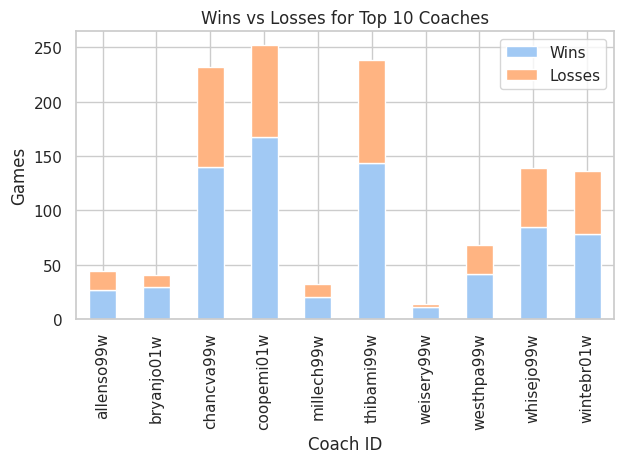

In [59]:
# Distribution of wins and losses for top coaches
top_coach_ids = top_coaches.index.tolist()
top_coach_stats = coaches_copy[coaches_copy['coachID'].isin(top_coach_ids)].groupby('coachID')[['won', 'lost']].sum()

plt.figure(figsize=(10, 6))
top_coach_stats.plot(kind='bar', stacked=True)
plt.title('Wins vs Losses for Top 10 Coaches')
plt.xlabel('Coach ID')
plt.ylabel('Games')
plt.legend(['Wins', 'Losses'])
plt.tight_layout()
plt.show()

/tmp/ipykernel_16776/2969141010.py:3: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  coach_win_pct = coaches_copy.groupby('coachID').apply(


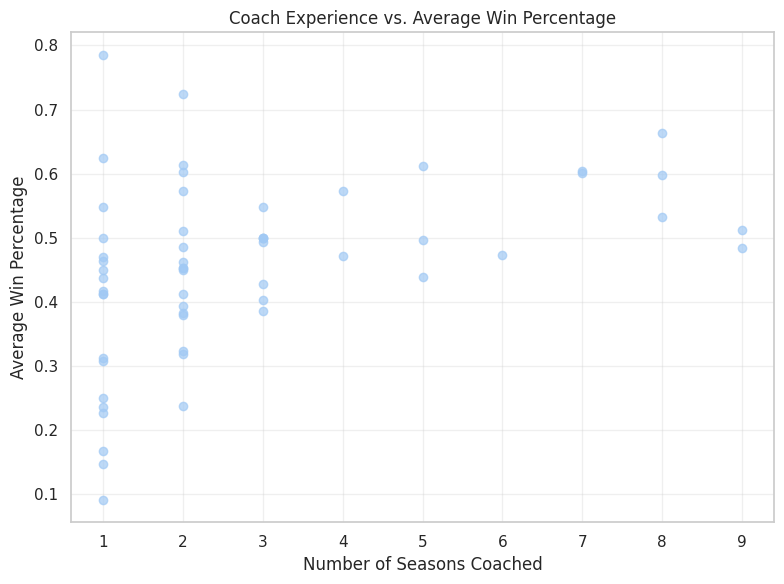

In [60]:
# Coach experience vs. average win percentage
coach_experience = coaches_copy.groupby('coachID')['year'].nunique()
coach_win_pct = coaches_copy.groupby('coachID').apply(
    lambda x: x['won'].sum() / (x['won'].sum() + x['lost'].sum())
)

plt.figure(figsize=(8, 6))
plt.scatter(coach_experience, coach_win_pct, alpha=0.7)
plt.title('Coach Experience vs. Average Win Percentage')
plt.xlabel('Number of Seasons Coached')
plt.ylabel('Average Win Percentage')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

**Insight:** Coaches with more seasons tend to cluster around the middle win percentage (about 0.5–0.6). Coaches with only 1–2 seasons have a wide range of win percentages.

### Coach Change Analysis

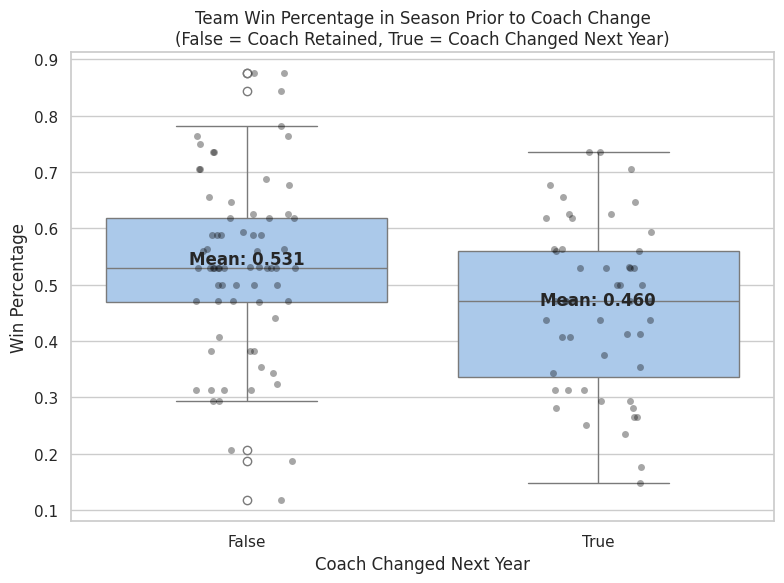

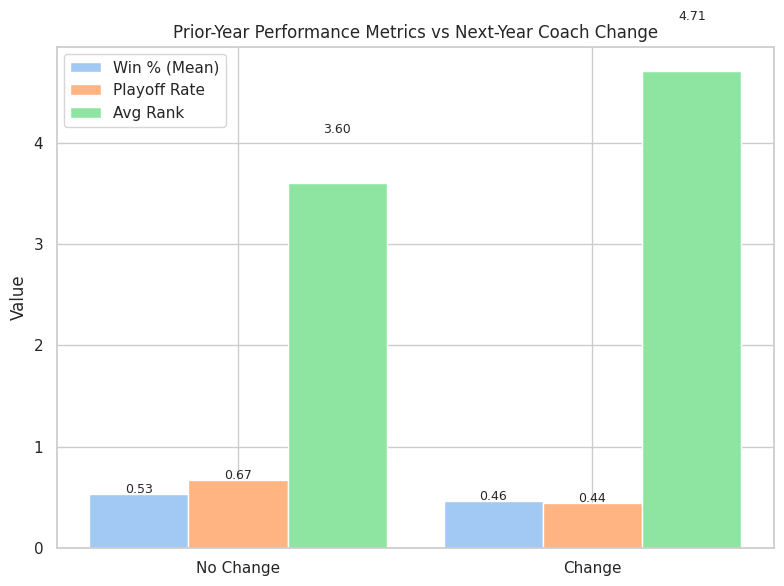

In [61]:
# Coach Change Performance (prior-year metrics)
coaches_year = (
    coaches_df
    .groupby(['tmID', 'year'])['coachID']
    .agg(lambda x: ','.join(sorted(x.unique())))
    .reset_index()
    .sort_values(['tmID', 'year'])
)

coaches_year['next_year_coach'] = coaches_year.groupby('tmID')['coachID'].shift(-1)
coaches_year['coach_changed_next_year'] = coaches_year['coachID'] != coaches_year['next_year_coach']

teams_perf = teams_df.copy()
teams_perf['win_pct'] = teams_perf['won'] / (teams_perf['won'] + teams_perf['lost'])

merge_perf = coaches_year.merge(
    teams_perf[['tmID', 'year', 'win_pct', 'playoff', 'rank']],
    on=['tmID', 'year'],
    how='left'
)

analysis_df = merge_perf.dropna(subset=['next_year_coach']).copy()
analysis_df['made_playoffs'] = (analysis_df['playoff'] == 'Y').astype(int)

import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))
sns.boxplot(data=analysis_df, x='coach_changed_next_year', y='win_pct')
sns.stripplot(data=analysis_df, x='coach_changed_next_year', y='win_pct',
              color='black', alpha=0.35, jitter=0.15)

means = analysis_df.groupby('coach_changed_next_year')['win_pct'].mean()
for i, v in enumerate(means):
    plt.text(i, v + 0.005, f'Mean: {v:.3f}', ha='center', fontweight='bold')

plt.title('Team Win Percentage in Season Prior to Coach Change\n(False = Coach Retained, True = Coach Changed Next Year)')
plt.xlabel('Coach Changed Next Year')
plt.ylabel('Win Percentage')
plt.tight_layout()
plt.show()

summary = (analysis_df.groupby('coach_changed_next_year')
           .agg(win_pct_mean=('win_pct', 'mean'),
                playoff_rate=('made_playoffs', 'mean'),
                avg_rank=('rank', 'mean'))
           .reset_index())

fig, ax = plt.subplots(figsize=(8, 6))
x = np.arange(len(summary))
width = 0.28

ax.bar(x - width, summary['win_pct_mean'], width, label='Win % (Mean)')
ax.bar(x, summary['playoff_rate'], width, label='Playoff Rate')
ax.bar(x + width, summary['avg_rank'], width, label='Avg Rank')

ax.set_xticks(x)
ax.set_xticklabels(summary['coach_changed_next_year'].map({False: 'No Change', True: 'Change'}))
ax.set_ylabel('Value')
ax.set_title('Prior-Year Performance Metrics vs Next-Year Coach Change')
ax.legend()

for i in x:
    ax.text(i - width, summary.loc[i, 'win_pct_mean'] + 0.01,
            f"{summary.loc[i, 'win_pct_mean']:.2f}", ha='center', fontsize=9)
    ax.text(i, summary.loc[i, 'playoff_rate'] + 0.01,
            f"{summary.loc[i, 'playoff_rate']:.2f}", ha='center', fontsize=9)
    ax.text(i + width, summary.loc[i, 'avg_rank'] + 0.5,
            f"{summary.loc[i, 'avg_rank']:.2f}", ha='center', fontsize=9)

plt.tight_layout()
plt.show()

**Insight**: Teams that changed coaches had a worse performance than teams that didn't in the year prior to the change, as evidenced by the win percentage, playoff rate and average rank.

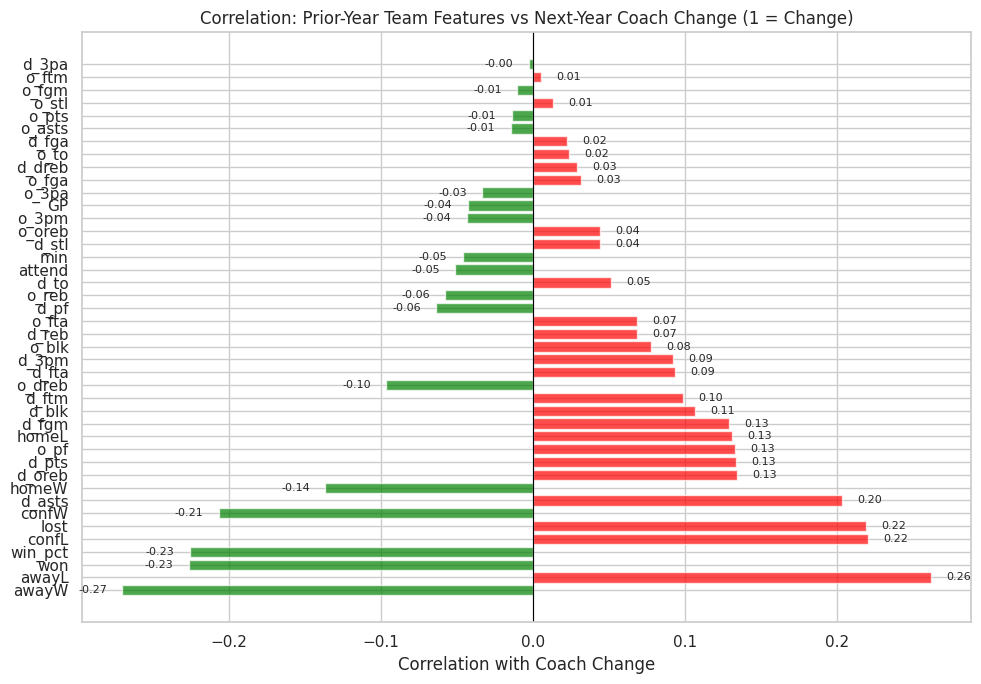

In [62]:
change_df = analysis_df.copy()
change_df['coach_changed_next_year'] = change_df['coach_changed_next_year'].astype(int)

team_num = teams_df.select_dtypes(include='number')
cols_exclude = {
    'year','seeded','tmORB','tmDRB','tmTRB',
    'opptmORB','opptmDRB','opptmTRB'
}
keep_cols = [c for c in team_num.columns if c not in cols_exclude]

extra_feats = teams_df[['tmID','year'] + keep_cols]
change_feat_df = change_df.merge(extra_feats, on=['tmID','year'], how='left')

def valid(col):
    return col not in ['coach_changed_next_year'] and change_feat_df[col].nunique() > 1 and change_feat_df[col].isna().sum() == 0

feature_cols = [c for c in keep_cols + ['win_pct','rank'] if c in change_feat_df.columns and valid(c)]

corr_series = change_feat_df[feature_cols + ['coach_changed_next_year']].corr()['coach_changed_next_year'].drop('coach_changed_next_year')
corr_sorted = corr_series.reindex(corr_series.abs().sort_values(ascending=False).index)

plt.figure(figsize=(10, 7))
colors = ['red' if v > 0 else 'green' for v in corr_sorted.values]
plt.barh(range(len(corr_sorted)), corr_sorted.values, color=colors, alpha=0.7)
plt.yticks(range(len(corr_sorted)), corr_sorted.index)
plt.xlabel('Correlation with Coach Change')
plt.title('Correlation: Prior-Year Team Features vs Next-Year Coach Change (1 = Change)')
plt.axvline(0, color='black', linewidth=0.8)
for i, v in enumerate(corr_sorted.values):
    plt.text(v + (0.01 if v > 0 else -0.01), i, f'{v:.2f}',
             va='center', ha='left' if v > 0 else 'right', fontsize=8)
plt.tight_layout()
plt.show()

**Insight**: Poor team results are the strongest predictors of a coaching change, more so than offensive and defensive statistics.

### PLAYER ANALYSIS

#### Player Physical Attributes Analysis

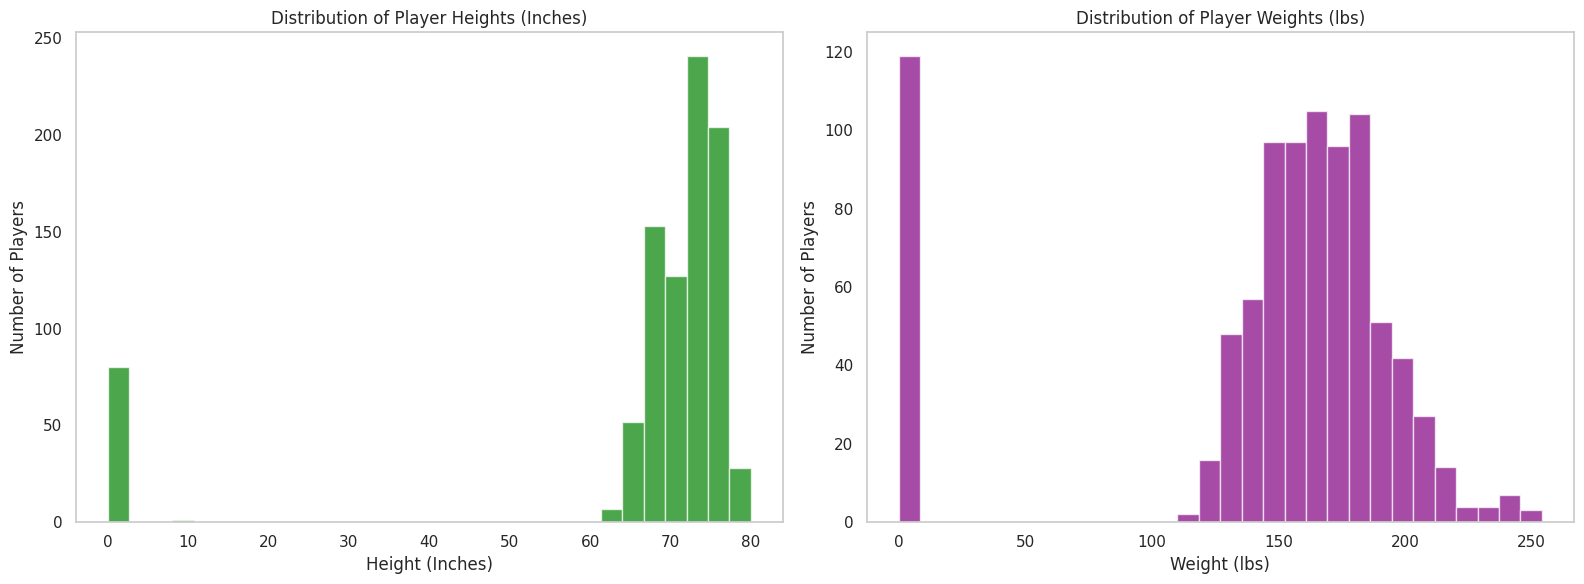

In [63]:
# Distribution of player heights and weights side by side
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

players_copy['height'].hist(bins=30, color='green', alpha=0.7, ax=axes[0])
axes[0].set_title('Distribution of Player Heights (Inches)')
axes[0].set_xlabel('Height (Inches)')
axes[0].set_ylabel('Number of Players')
axes[0].grid(False)

players_copy['weight'].hist(bins=30, color='purple', alpha=0.7, ax=axes[1])
axes[1].set_title('Distribution of Player Weights (lbs)')
axes[1].set_xlabel('Weight (lbs)')
axes[1].set_ylabel('Number of Players')
axes[1].grid(False)

plt.tight_layout()
plt.show()

**Data Quality Issue:** These graphs show that data cleaning is needed, as there are several players with the height and weight recorded as 0.

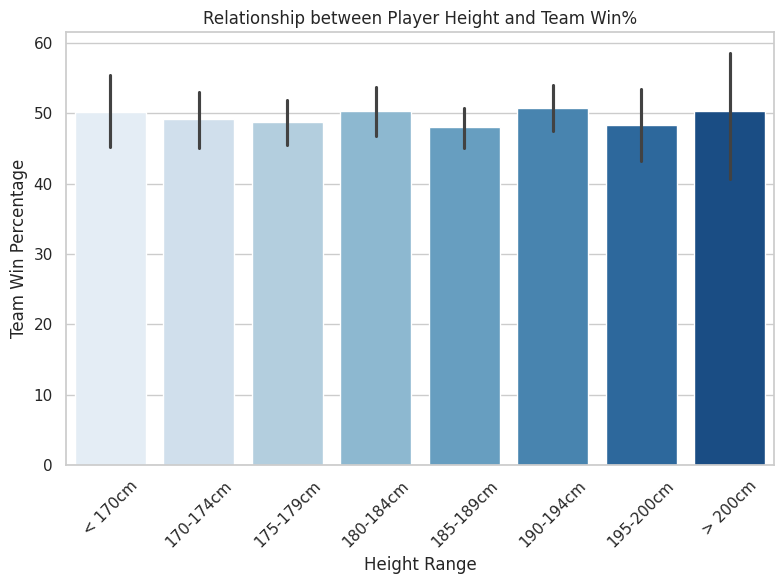

In [64]:
# Relationship between player height and team win percentage
teams_work_temp = teams_copy.copy()
teams_work_temp['win_pct'] = (teams_work_temp['won'] / teams_work_temp['GP']) * 100

merged_height = pd.merge(
    players_teams_copy, 
    teams_work_temp[["year", "tmID", "win_pct"]], 
    on=["year", "tmID"], 
    how="left"
)

merged_height = merged_height.drop_duplicates(subset=["playerID"], keep="first")
merged_height = pd.merge(
    merged_height, 
    players_copy[["bioID", "height"]], 
    left_on="playerID", 
    right_on='bioID', 
    how="left"
)

# Convert inches to cm
merged_height['height_cm'] = merged_height['height'] * 2.54

# Create height bins
bins = [0, 170, 175, 180, 185, 190, 195, 200, 230]
labels = [
    '< 170cm', '170-174cm', '175-179cm', '180-184cm',
    '185-189cm', '190-194cm', '195-200cm', '> 200cm'
]
merged_height['height_bin'] = pd.cut(merged_height['height_cm'], bins=bins, labels=labels, right=False)

plt.figure(figsize=(8, 6))
plt.title('Relationship between Player Height and Team Win%')
sns.barplot(data=merged_height, x='height_bin', y='win_pct', hue='height_bin', palette='Blues', legend=False)
plt.xlabel('Height Range')
plt.ylabel('Team Win Percentage')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

**Insight:** Average player height is not a strong predictor of team success.

#### Player Awards Analysis

In [65]:
# Top 10 players with the most awards
top_award_players = awards_players_copy['playerID'].value_counts().head(10)
print('Top 10 Players by Number of Awards')
display(top_award_players.reset_index().rename(columns={'count': 'Number of Awards'}))

Top 10 Players by Number of Awards


,playerID,Number of Awards
0,leslili01w,10
1,swoopsh01w,8
2,catchta01w,5
3,jacksla01w,4
4,tauradi01w,4
5,thompti01w,2
6,thibami99w,2
7,mcconsu01w,2
8,hugheda99w,2
9,fordch01w,2


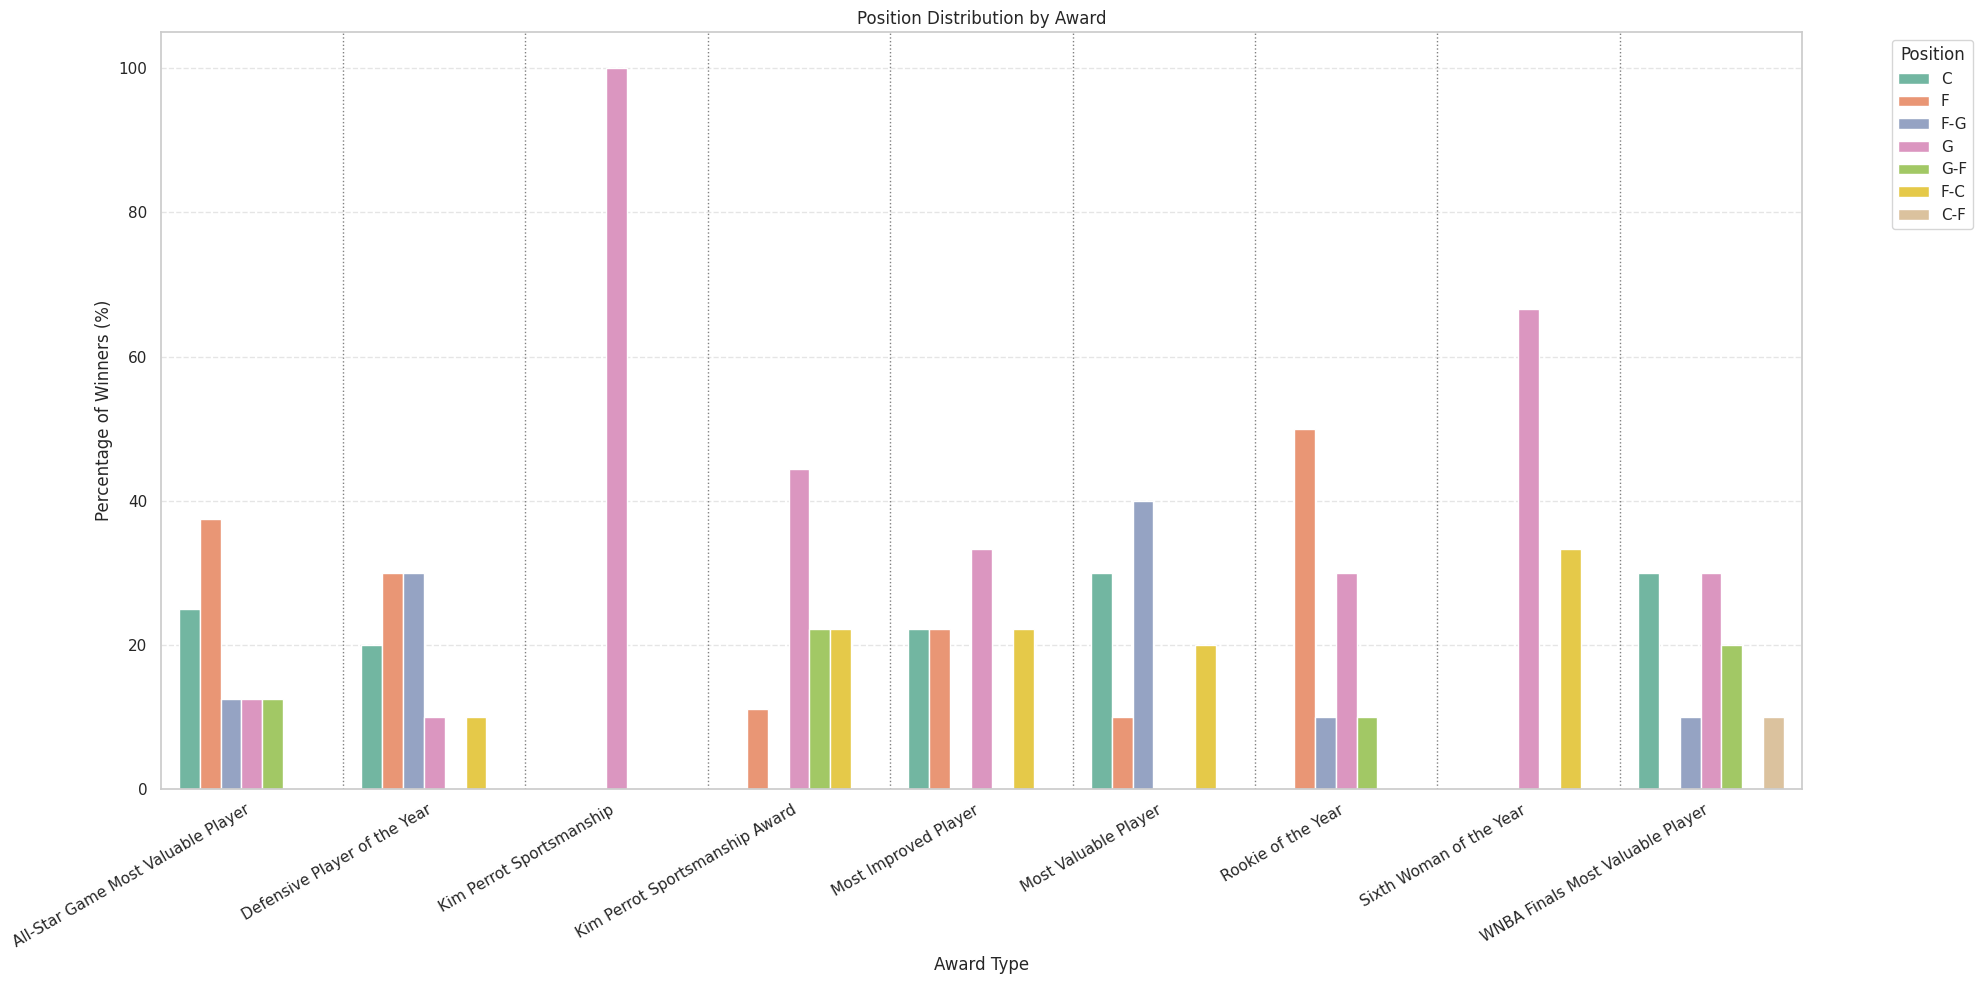

In [66]:
# Position-based award analysis (exclude Coach of the Year and All-Decade awards)
exclude_awards = [
    "Coach of the Year",
    "WNBA All-Decade Team",
    "WNBA All Decade Team Honorable Mention"
]
position_awards = awards_players_copy[
    ~awards_players_copy["award"].isin(exclude_awards)
].merge(
    players_copy,
    left_on="playerID",
    right_on="bioID",
    how="left"
)

# Count awards by position
position_awards_summary = position_awards.groupby(["award", "pos"]).size().reset_index(name="count")
position_awards_summary["percentage"] = (
    position_awards_summary.groupby("award")["count"].transform(lambda x: 100 * x / x.sum())
)

# Visualization
plt.figure(figsize=(20, 10))

sns.barplot(
    data=position_awards_summary,
    x="award",
    y="percentage",
    hue="pos",
    palette="Set2"
)

plt.title("Position Distribution by Award")
plt.ylabel("Percentage of Winners (%)")
plt.xlabel("Award Type")
plt.xticks(rotation=30, ha="right")
plt.legend(title="Position", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(axis='y', linestyle='--', alpha=0.5)

for i in range(len(position_awards_summary['award'].unique()) - 1):
    plt.axvline(i + 0.5, color='gray', linestyle=':', linewidth=1)

plt.tight_layout()
plt.show()
plt.show()

**Data Quality Issue**: There are two distinct names for the same award (Kim Perrot Sportsmanship). The name should be standardized.

**Insight:** Certain positions are much more likely to win specific awards. For example, guards dominate awards like Sixth Woman of the Year and Sportsmanship, while forwards and centers are more likely to win MVP.

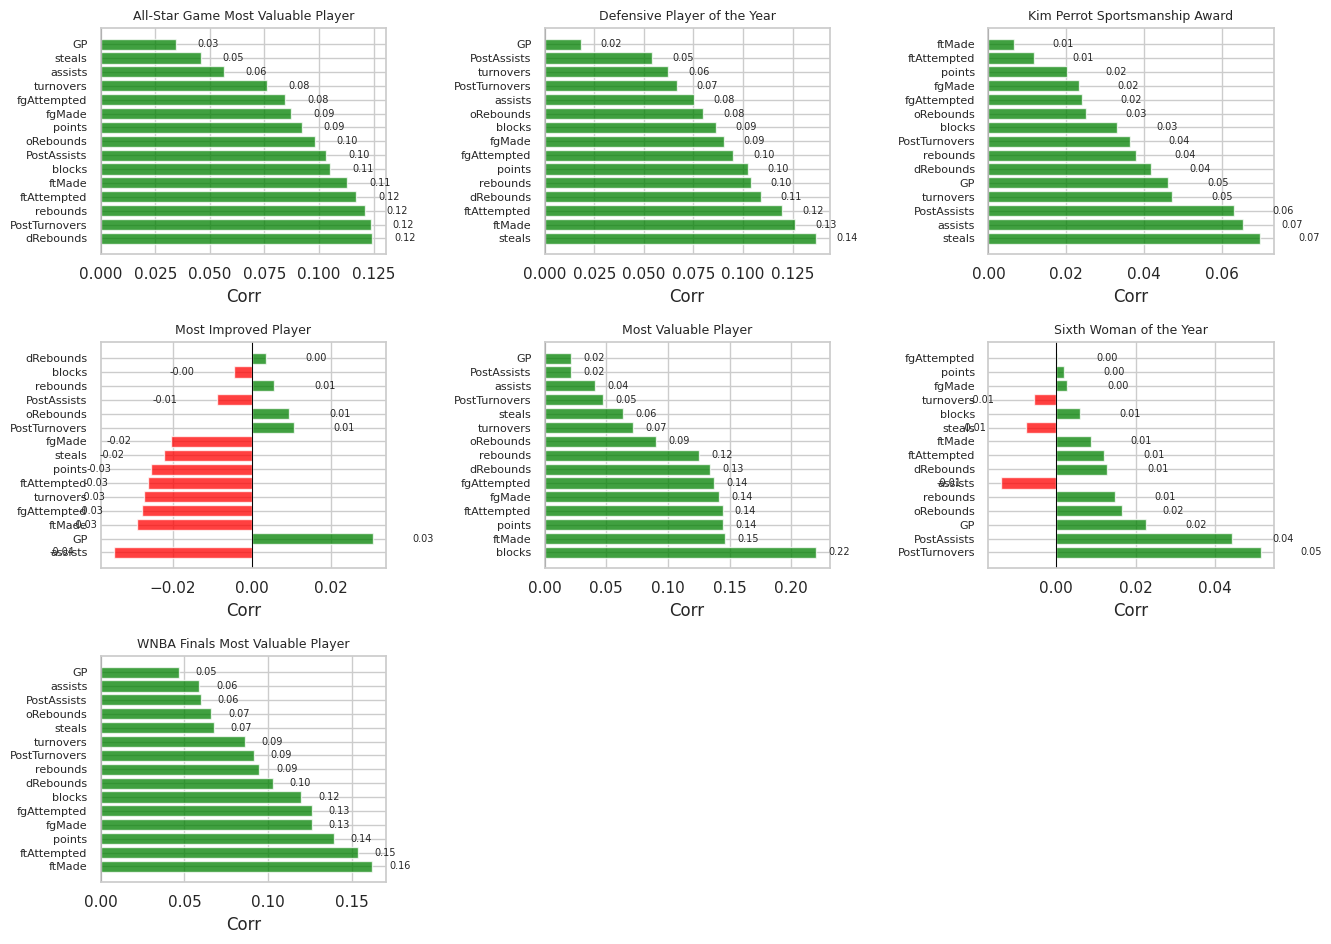

In [67]:
exclude_awards = {
    "Coach of the Year",
    "WNBA All-Decade Team",
    "WNBA All Decade Team Honorable Mention",
    "Kim Perrot Sportsmanship"
}

awards_filtered = awards_players_df[~awards_players_df['award'].isin(exclude_awards)].copy()

award_names = sorted(awards_filtered['award'].unique())

raw_cols = [
    'GP','points','rebounds','assists','steals','blocks',
    'oRebounds','dRebounds','turnovers','fgMade','fgAttempted',
    'ftMade','ftAttempted','PostAssists','PostTurnovers'
]
present_cols = [c for c in raw_cols if c in players_teams_df.columns]

season_player = (
    players_teams_df
    .groupby(['playerID','year'])[present_cols]
    .sum()
    .reset_index()
)

season_player = season_player[season_player['GP'] >= 10].copy()
season_player = season_player.sort_values(['playerID','year'])

def build_next_year_flag(df_season, award_df, award_name):
    a_df = award_df[award_df['award'] == award_name][['year','playerID']].rename(columns={'year':'award_year'})
    return df_season.apply(
        lambda r: int(((a_df['award_year'] == r['year'] + 1) & (a_df['playerID'] == r['playerID'])).any()),
        axis=1
    )

def valid_feature(col):
    return season_player[col].nunique() > 1 and season_player[col].isna().sum() == 0

feature_cols = [c for c in present_cols if valid_feature(c)]

correlation_results = {}
award_positive_counts = {}

# Compute correlations per award
for aw in award_names:
    target_col = 'next_year_flag'
    season_player[target_col] = build_next_year_flag(season_player, awards_filtered, aw)
    # Skip if no positives
    pos_count = season_player[target_col].sum()
    award_positive_counts[aw] = int(pos_count)
    if pos_count == 0:
        continue
    corr_series = season_player[feature_cols + [target_col]].corr()[target_col].drop(target_col)
    correlation_results[aw] = corr_series.reindex(corr_series.abs().sort_values(ascending=False).index)

import math
n_awards_plot = len(correlation_results)
cols = 3
rows = math.ceil(n_awards_plot / cols)
plt.figure(figsize=(cols * 4.5, rows * 3.2))

idx = 1
for aw, corr_ser in correlation_results.items():
    plt.subplot(rows, cols, idx)
    colors = ['green' if v > 0 else 'red' for v in corr_ser.values]
    plt.barh(range(len(corr_ser)), corr_ser.values, color=colors, alpha=0.75)
    plt.yticks(range(len(corr_ser)), corr_ser.index, fontsize=8)
    plt.axvline(0, color='black', linewidth=0.7)
    plt.title(f"{aw}", fontsize=9)
    plt.xlabel("Corr")
    for i, v in enumerate(corr_ser.values):
        plt.text(v + (0.01 if v > 0 else -0.01), i, f"{v:.2f}",
                 va='center', ha='left' if v > 0 else 'right', fontsize=7)
    idx += 1

plt.tight_layout()
plt.show()

**Insight**: Some awards, namely "Most Improved Player", "Sixth Woman of the Year" and "Kim Perrot Sportsmanship Award", appear to be largely based on subjective factors rather than on player statistics, given the very low correlation values.

#### Player Performance Metrics

In [68]:
# Calculate per-game averages for key stats
players_teams_copy['ppg'] = players_teams_copy['points'] / players_teams_copy['GP']
players_teams_copy['apg'] = players_teams_copy['assists'] / players_teams_copy['GP']
players_teams_copy['rpg'] = players_teams_copy['rebounds'] / players_teams_copy['GP']
players_teams_copy['spg'] = players_teams_copy['steals'] / players_teams_copy['GP']
players_teams_copy['bpg'] = players_teams_copy['blocks'] / players_teams_copy['GP']

In [69]:
# Top 10 players by points per game (minimum 10 games played)
ppg_leaders = players_teams_copy[players_teams_copy['GP'] >= 10].groupby('playerID')['ppg'].mean().sort_values(ascending=False).head(10)

print('Top 10 Players by Points Per Game (Min. 10 Games)')
display(ppg_leaders.reset_index().rename(columns={'playerID': 'Player ID', 'ppg': 'Points Per Game'}))

Top 10 Players by Points Per Game (Min. 10 Games)


,Player ID,Points Per Game
0,augusse01w,21.188172
1,tauradi01w,20.315425
2,jacksla01w,19.376303
3,pondeca01w,19.234716
4,reedbr01w,19.000000
5,coopecy01w,17.741935
6,holdsch01w,17.447299
7,leslili01w,17.323630
8,thompti01w,16.838765
9,catchta01w,16.366309


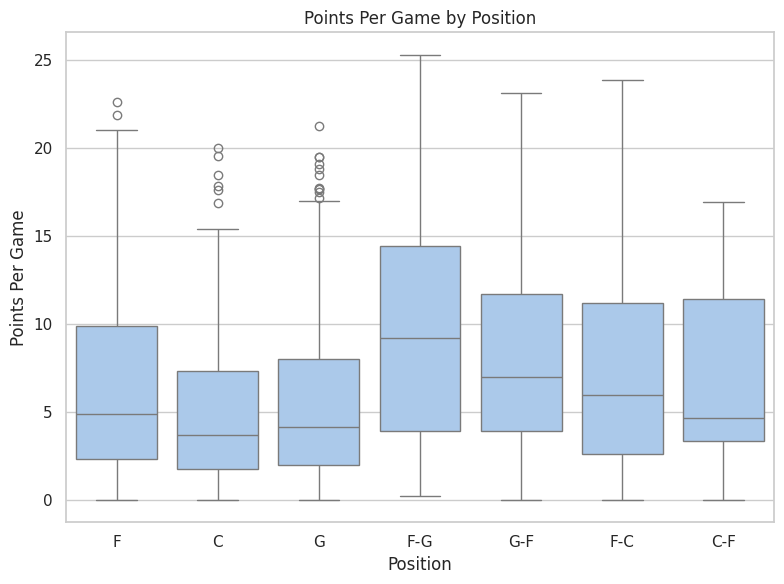

In [70]:
# Boxplot: Points per game by position
merged_pos = pd.merge(
    players_teams_copy, 
    players_copy[['bioID', 'pos']], 
    left_on='playerID', 
    right_on='bioID', 
    how='left'
)
boxplot_data = merged_pos[['pos', 'ppg']].dropna()

plt.figure(figsize=(8, 6))
sns.boxplot(x='pos', y='ppg', data=boxplot_data)
plt.title('Points Per Game by Position')
plt.xlabel('Position')
plt.ylabel('Points Per Game')
plt.tight_layout()
plt.show()

**Insight:** Players in forward positions are generally more productive scorers, as expected.

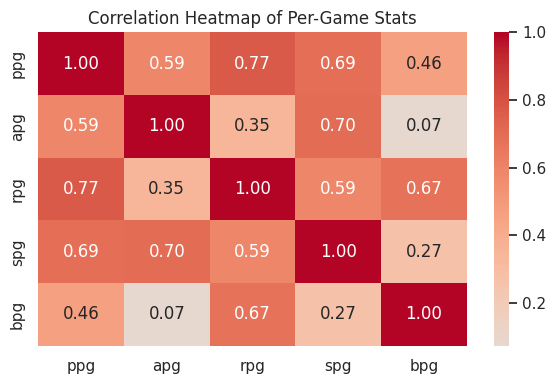

In [71]:
# Heatmap: Correlation between advanced stats
corr_stats = players_teams_copy[['ppg', 'apg', 'rpg', 'spg', 'bpg']].corr()

plt.figure(figsize=(6, 4))
sns.heatmap(corr_stats, annot=True, cmap='coolwarm', fmt='.2f', center=0)
plt.title('Correlation Heatmap of Per-Game Stats')
plt.tight_layout()
plt.show()

**Key Correlations:**
- Points (ppg) and rebounds (rpg) are highly correlated: players who score more also tend to rebound more
- Points and assists (apg) are moderately correlated, suggesting high scorers also often assist more
- Strong correlation between assists and steals (spg), indicating playmakers are active defensively
- Blocks (bpg) are weakly correlated with assists and steals, but more with rebounds

#### Player Efficiency Ratings

In [72]:
# Calculate NBA Player Efficiency Rating (PER)
# Formula: (PTS + REB + AST + STL + BLK − ((FGA − FGM) + (FTA − FTM) + TO)) / GP
players_teams_copy["NBA_PER"] = (
    players_teams_copy['points'] + 
    players_teams_copy['rebounds'] + 
    players_teams_copy['assists'] + 
    players_teams_copy['steals'] + 
    players_teams_copy['blocks'] -
    ((players_teams_copy['fgAttempted'] - players_teams_copy['fgMade']) + 
     (players_teams_copy['ftAttempted'] - players_teams_copy['ftMade']) + 
     players_teams_copy['turnovers'])
) / players_teams_copy["GP"]

print(f"Mean PER: {players_teams_copy['NBA_PER'].mean():.2f}")
print(f"Median PER: {players_teams_copy['NBA_PER'].median():.2f}")

Mean PER: 6.46
Median PER: 5.18


In [73]:
# Top performers by year (based on PER)
top_by_year = (
    players_teams_copy
    .groupby('year', group_keys=False)
    .apply(lambda x: x.nlargest(1, 'NBA_PER'))
)

print("Top player by PER for each year:")
display(top_by_year[['year', 'playerID', 'tmID', 'NBA_PER']].sort_values('year'))

Top player by PER for each year:


/tmp/ipykernel_16776/73123641.py:5: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.nlargest(1, 'NBA_PER'))


,year,playerID,tmID,NBA_PER
1576,1,swoopsh01w,HOU,23.548387
573,2,griffyo01w,SAC,22.687500
278,3,catchta01w,IND,23.562500
732,4,jacksla01w,SEA,24.121212
907,5,leslili01w,LAS,22.735294
734,6,jacksla01w,SEA,21.676471
735,7,jacksla01w,SEA,23.700000
736,8,jacksla01w,SEA,27.580645
1224,9,parkeca01w,LAS,24.212121
1590,10,tauradi01w,PHO,21.387097


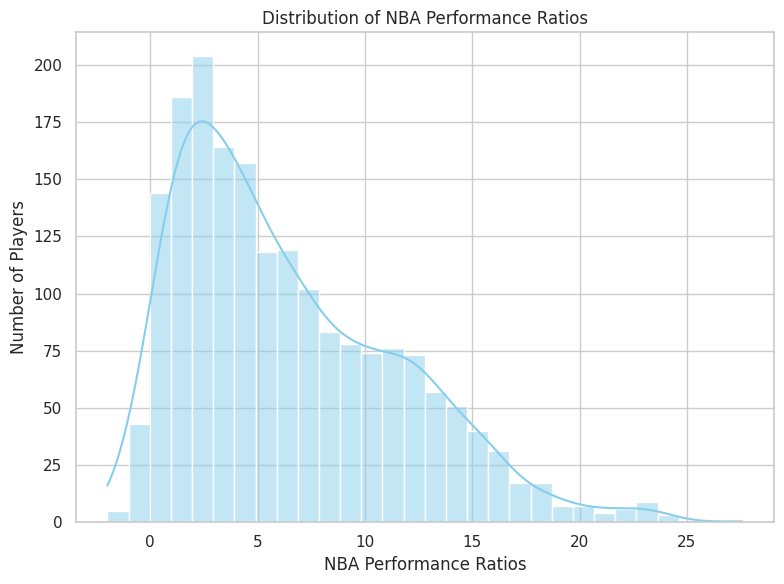

In [74]:
# Distribution of NBA PER
plt.figure(figsize=(8, 6))
sns.histplot(players_teams_copy['NBA_PER'], bins=30, kde=True, color='skyblue')
plt.title('Distribution of NBA Performance Ratios')
plt.xlabel('NBA Performance Ratios')
plt.ylabel('Number of Players')
plt.tight_layout()
plt.show()

In [75]:
# True Shooting Percentage
players_teams_copy["ts_pct"] = players_teams_copy['points'] / (
    2 * (players_teams_copy["fgAttempted"] + (0.44 * players_teams_copy["ftAttempted"]))
)

print(f"Mean TS%: {players_teams_copy['ts_pct'].mean():.3f}")
print(f"Median TS%: {players_teams_copy['ts_pct'].median():.3f}")

Mean TS%: 0.473
Median TS%: 0.494


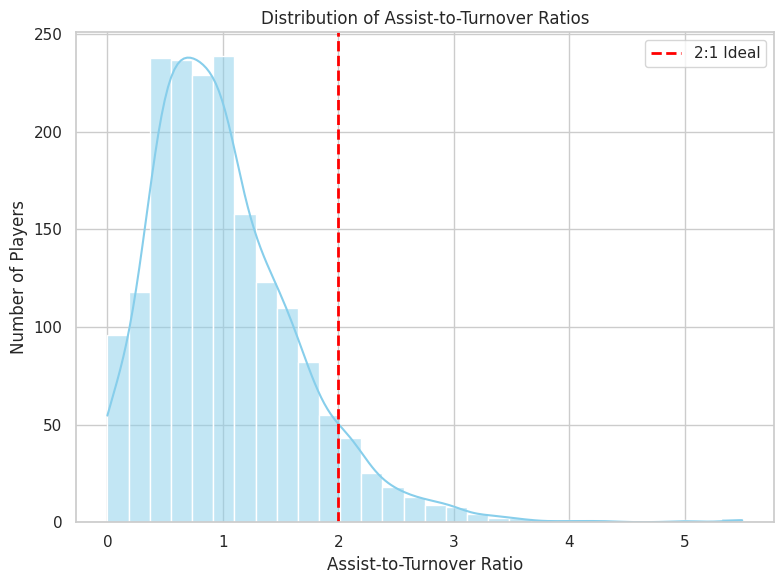

In [76]:
# Assist to Turnover Ratio
players_teams_copy["ast_to"] = (
    (players_teams_copy["assists"] + players_teams_copy["PostAssists"]) / 
    (players_teams_copy["turnovers"] + players_teams_copy["PostTurnovers"])
)

plt.figure(figsize=(8, 6))
sns.histplot(players_teams_copy['ast_to'], bins=30, kde=True, color='skyblue')
plt.axvline(2, color='red', linestyle='--', label='2:1 Ideal', linewidth=2)
plt.title('Distribution of Assist-to-Turnover Ratios')
plt.xlabel('Assist-to-Turnover Ratio')
plt.ylabel('Number of Players')
plt.legend()
plt.tight_layout()
plt.show()

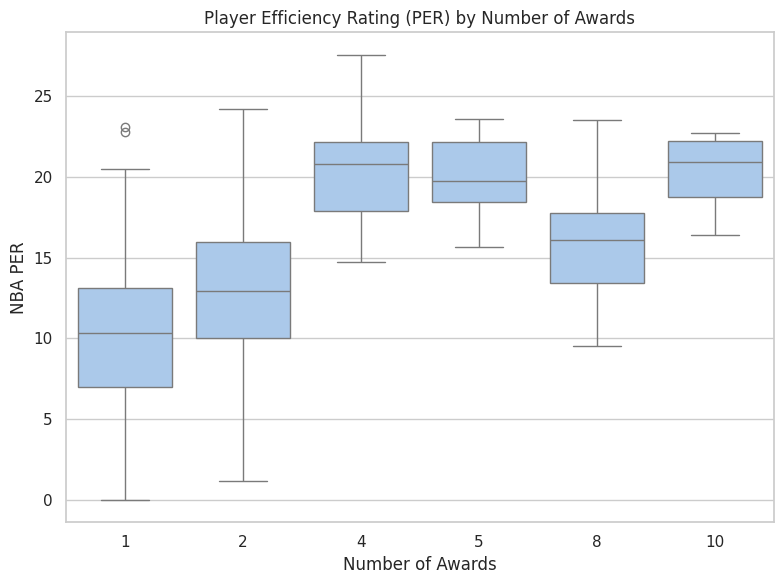

In [77]:
# PER by number of awards
award_counts = awards_players_copy.groupby(['playerID']).size().reset_index(name='num_awards')
num_awards_df = players_teams_copy.merge(award_counts, on="playerID")

plt.figure(figsize=(8, 6))
sns.boxplot(data=num_awards_df, x='num_awards', y='NBA_PER')
plt.title('Player Efficiency Rating (PER) by Number of Awards')
plt.xlabel('Number of Awards')
plt.ylabel('NBA PER')
plt.tight_layout()
plt.show()

**Insight:** In general, players with more awards have higher median PER values, suggesting this could be a good predictor of individual awards.

#### Player Award Analysis

In [78]:
# Compare award winners vs non-winners
p_awards = players_teams_copy.merge(awards_players_copy, on=["playerID", "year"], how="left")

# Create binary indicator: 1 if player won an award, 0 otherwise
p_awards["award_winner"] = p_awards["award"].notnull().astype(int)

stats = [
    "points", "rebounds", "assists", "steals", "blocks",
    "oRebounds", "dRebounds", "turnovers", "fgMade", "fgAttempted", "NBA_PER",
]

# Drop null values
p_awards_clean = p_awards.dropna(subset=stats)

# Calculate mean comparison
mean_comparison = (
    p_awards_clean.groupby("award_winner")[stats]
    .mean()
    .rename(index={0: "Non-Winners", 1: "Award Winners"})
    .T
)

mean_comparison["Win/NonWin Ratio"] = mean_comparison.apply(
    lambda row: row["Award Winners"] / row["Non-Winners"], axis=1
)

mean_comparison = mean_comparison.round(2)

print("Average performance metrics for award winners vs non-winners:")
display(mean_comparison)

Average performance metrics for award winners vs non-winners:


award_winner,Non-Winners,Award Winners,Win/NonWin Ratio
points,166.14,464.16,2.79
rebounds,74.93,188.21,2.51
assists,37.18,89.48,2.41
steals,18.64,46.23,2.48
blocks,8.51,28.34,3.33
oRebounds,23.45,50.44,2.15
dRebounds,51.48,137.77,2.68
turnovers,35.03,76.80,2.19
fgMade,60.51,165.73,2.74
fgAttempted,144.48,366.40,2.54


**Insight**: Award winners significantly outperform non-winners across all major statistical categories by a factor of 2 or more. This confirms that traditional box score stats are strong indicators of award potential.

#### Position-Based Analysis

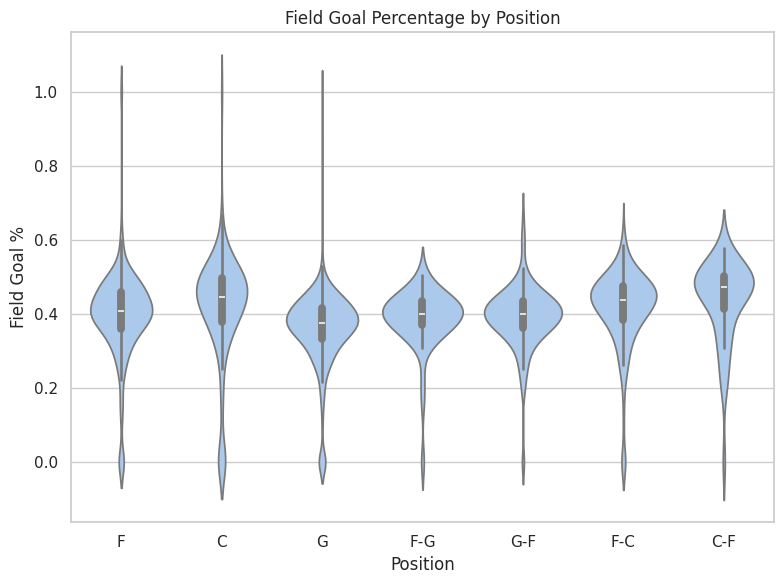

In [79]:
# Field goal percentage by position
players_teams_copy['fg_pct'] = players_teams_copy['fgMade'] / players_teams_copy['fgAttempted']

merged_fg = pd.merge(
    players_teams_copy, 
    players_copy[['bioID', 'pos']], 
    left_on='playerID', 
    right_on='bioID', 
    how='left'
)

plt.figure(figsize=(8, 6))
sns.violinplot(x='pos', y='fg_pct', data=merged_fg)
plt.title('Field Goal Percentage by Position')
plt.xlabel('Position')
plt.ylabel('Field Goal %')
plt.tight_layout()
plt.show()

**Insight:** Position affects shooting efficiency: centers and forwards are slightly more efficient, likely due to closer shots.

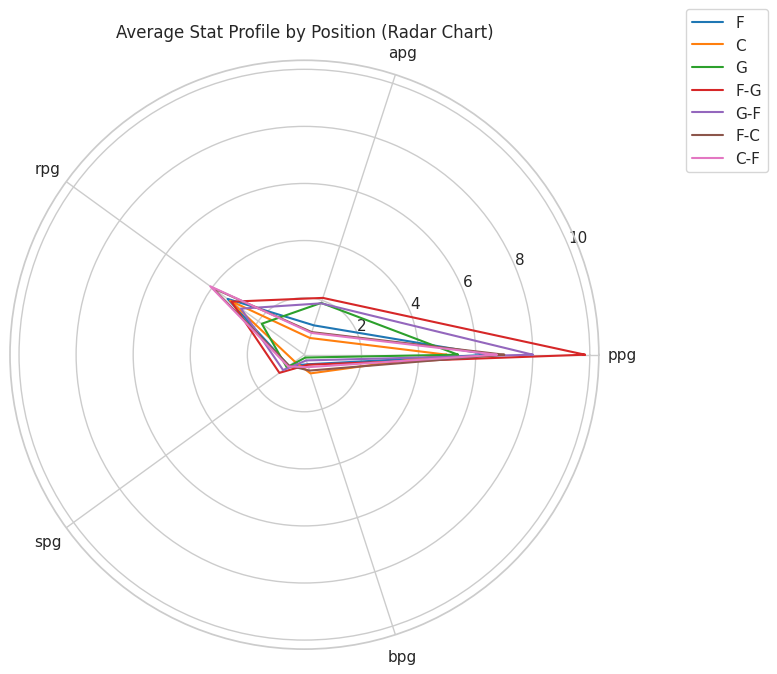

In [80]:
# Radar chart: Average stat profile for each position
positions = merged_fg['pos'].dropna().unique()
stat_cols = ['ppg', 'apg', 'rpg', 'spg', 'bpg']
angles = np.linspace(0, 2 * np.pi, len(stat_cols), endpoint=False).tolist()
angles += angles[:1]

colors = plt.get_cmap('tab10').colors

plt.figure(figsize=(8, 8))
for i, pos in enumerate(positions):
    values = merged_fg[merged_fg['pos'] == pos][stat_cols].mean().tolist()
    values += values[:1]
    plt.polar(angles, values, label=pos, color=colors[i % len(colors)])

plt.xticks(angles[:-1], stat_cols)
plt.title('Average Stat Profile by Position (Radar Chart)')
plt.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1))
plt.tight_layout()
plt.show()

**Position Profiles:**
- **Centers:** Rebounding and blocking
- **Guards:** Playmaking and steals
- **Forwards:** Scoring

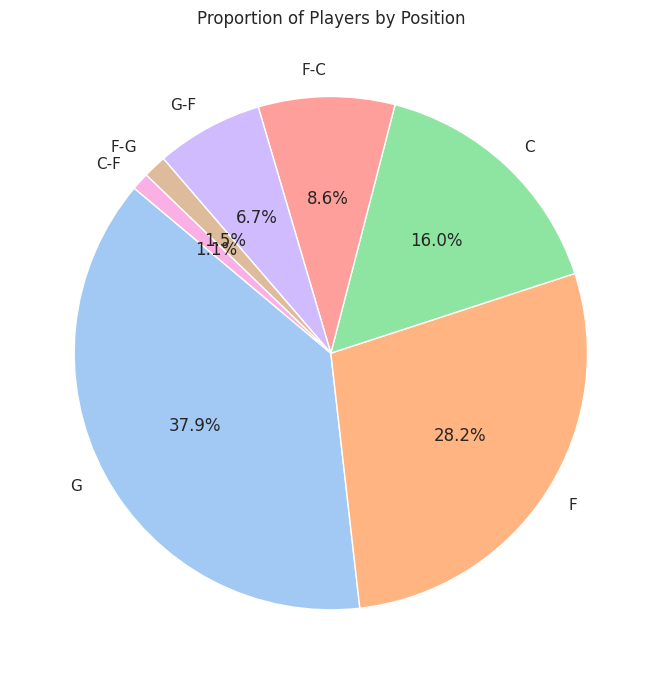

In [81]:
# Pie chart: Proportion of players by position
pos_counts = players_copy['pos'].value_counts()

plt.figure(figsize=(7, 7))
plt.pie(pos_counts, labels=pos_counts.index, autopct='%1.1f%%', startangle=140)
plt.title('Proportion of Players by Position')
plt.tight_layout()
plt.show()

**Data Imbalance Note:** There is a relevant class imbalance, as hybrid positions are much less frequent in the dataset.

### TEAM ANALYSIS

#### Team Performance Overview

In [82]:
teams_copy['win_pct'] = teams_copy['won'] / (teams_copy['won'] + teams_copy['lost'])

team_performance = teams_copy.groupby('name').agg({
    'won': 'sum',
    'lost': 'sum',
    'year': 'count'
}).rename(columns={'year': 'seasons'})

team_performance['total_games'] = team_performance['won'] + team_performance['lost']
team_performance['win_pct'] = team_performance['won'] / team_performance['total_games']

experienced_teams = team_performance[team_performance['seasons'] >= 3].sort_values('win_pct', ascending=False)

print('Top 10 Teams by Win Percentage (3+ Seasons)')
display(experienced_teams.head(10))

Top 10 Teams by Win Percentage (3+ Seasons)


,won,lost,seasons,total_games,win_pct
name,,,,,
Los Angeles Sparks,220,114,10,334,0.658683
Connecticut Sun,143,95,7,238,0.600840
Utah Starzz,57,39,3,96,0.593750
Houston Comets,170,130,9,300,0.566667
Sacramento Monarchs,187,147,10,334,0.559880
Detroit Shock,178,156,10,334,0.532934
New York Liberty,170,164,10,334,0.508982
Cleveland Rockers,66,64,4,130,0.507692
Indiana Fever,168,166,10,334,0.502994


#### Team Statistical Correlations

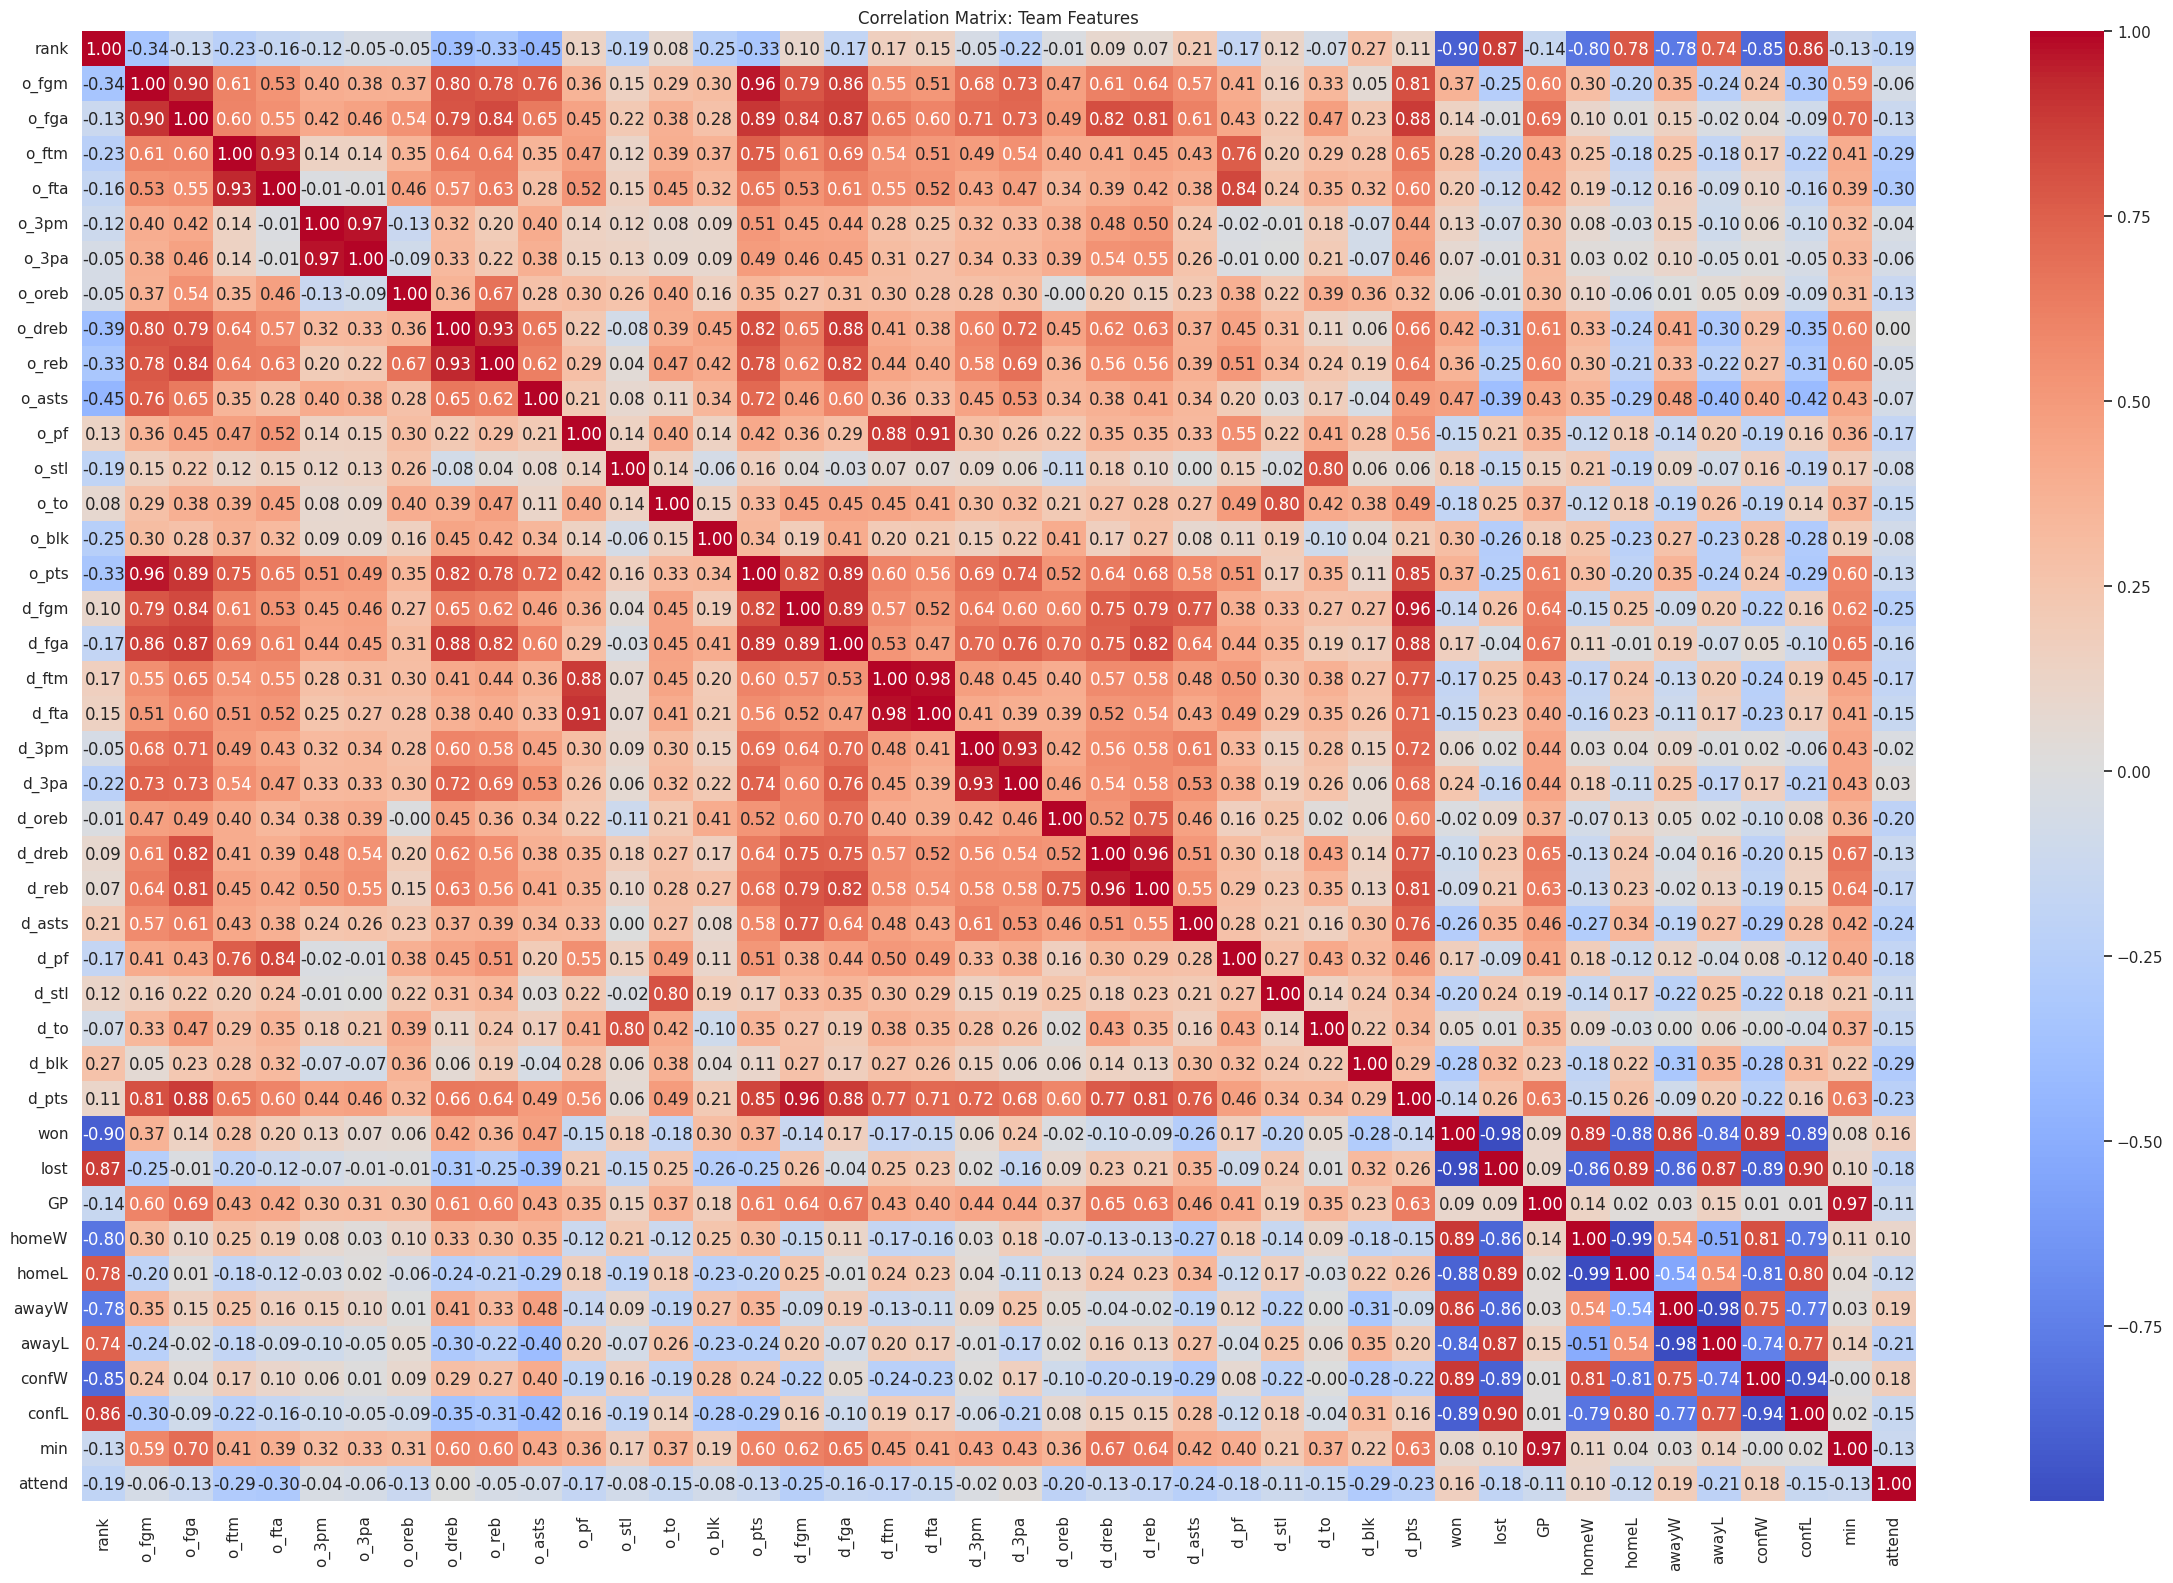

In [83]:
# Select numeric columns from teams_df, excluding irrelevant ones
teams_numeric = teams_df.select_dtypes(include='number').columns

# Remove columns that won't be useful for correlation analysis
cols_to_exclude = ['year', 'seeded', 'tmORB', 'tmDRB', 'tmTRB', 
                   'opptmORB', 'opptmDRB', 'opptmTRB', 'divID']
relevant_cols = [col for col in teams_numeric if col not in cols_to_exclude]

# Create correlation matrix
correlation_matrix = teams_df[relevant_cols].corr()

# Visualize correlation matrix
plt.figure(figsize=(24, 16))
sns.heatmap(correlation_matrix, annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Correlation Matrix: Team Features')
plt.tight_layout()
plt.show()

#### Playoff Performance Analysis

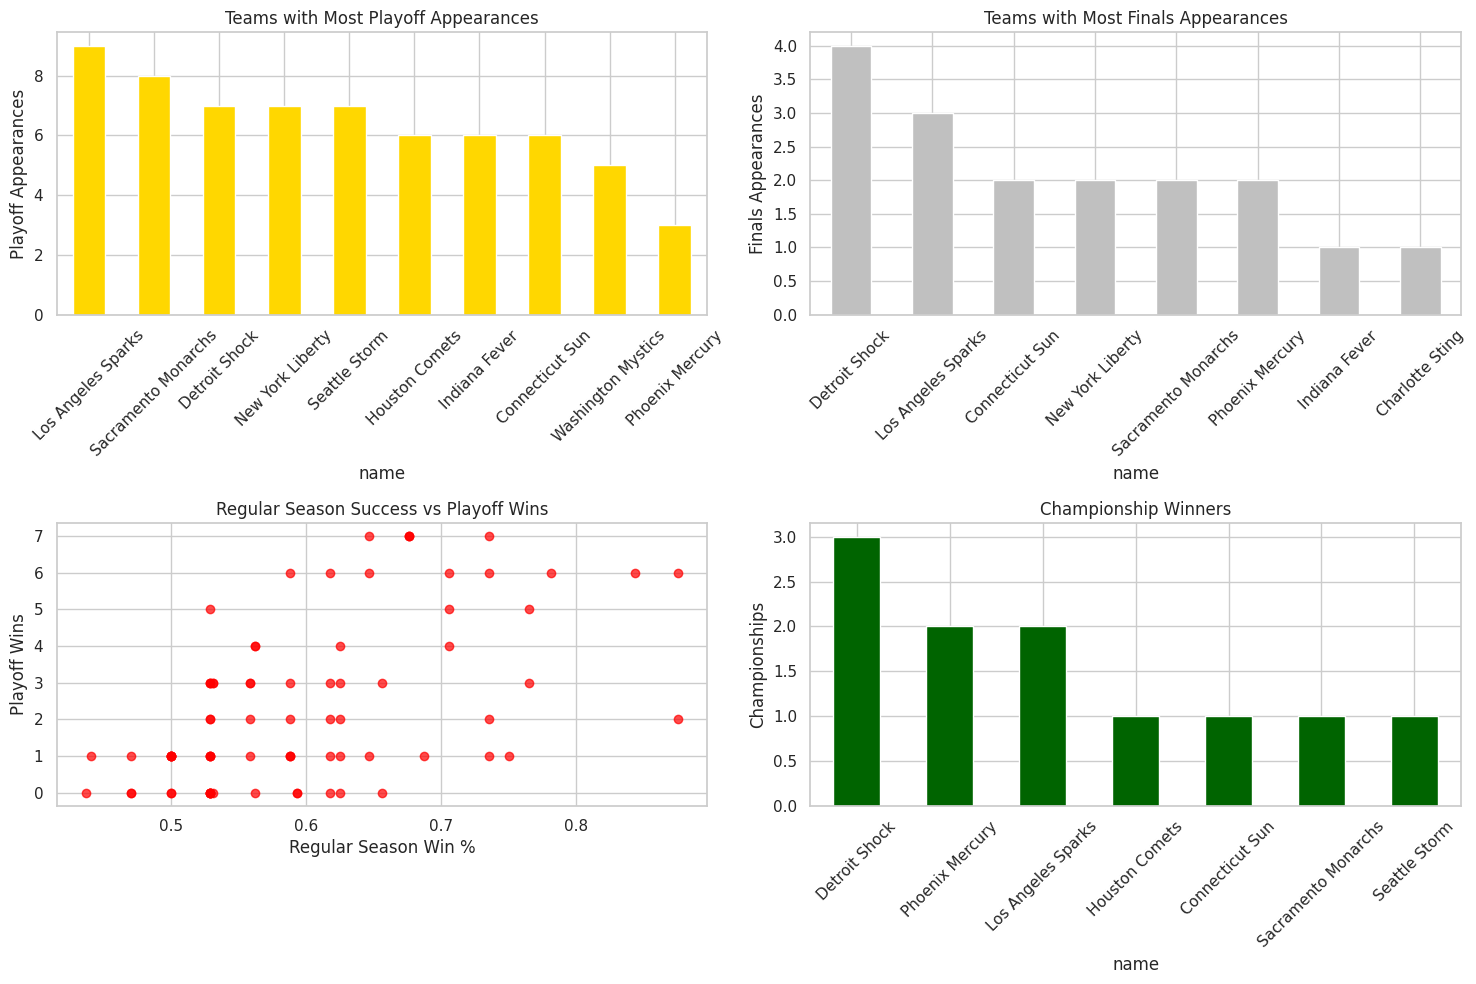

In [84]:
# Playoff participation analysis
playoff_teams = teams_copy[teams_copy['playoff'] == 'Y']
playoff_participation = teams_copy.groupby('name')['playoff'].apply(
    lambda x: (x == 'Y').sum()
).sort_values(ascending=False)

fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Teams with most playoff appearances
playoff_participation.head(10).plot(kind='bar', ax=axes[0, 0], color='gold')
axes[0, 0].set_title('Teams with Most Playoff Appearances')
axes[0, 0].set_ylabel('Playoff Appearances')
axes[0, 0].tick_params(axis='x', rotation=45)

# Finals appearances
finals_teams = teams_copy[teams_copy['finals'].notna()]
finals_appearances = teams_copy.groupby('name')['finals'].apply(
    lambda x: x.notna().sum()
).sort_values(ascending=False)
finals_appearances[finals_appearances > 0].head(8).plot(kind='bar', ax=axes[0, 1], color='silver')
axes[0, 1].set_title('Teams with Most Finals Appearances')
axes[0, 1].set_ylabel('Finals Appearances')
axes[0, 1].tick_params(axis='x', rotation=45)

# Regular season vs playoff performance
if not teams_post_copy.empty:
    playoff_merged = teams_copy.merge(teams_post_copy, on=['year', 'tmID'], suffixes=('_reg', '_playoff'))
    if not playoff_merged.empty:
        axes[1, 0].scatter(playoff_merged['win_pct'], playoff_merged['W'], alpha=0.7, color='red')
        axes[1, 0].set_xlabel('Regular Season Win %')
        axes[1, 0].set_ylabel('Playoff Wins')
        axes[1, 0].set_title('Regular Season Success vs Playoff Wins')

# Championship winners
champions = teams_copy[teams_copy['finals'] == 'W']
if not champions.empty:
    champion_counts = champions['name'].value_counts()
    champion_counts.plot(kind='bar', ax=axes[1, 1], color='darkgreen')
    axes[1, 1].set_title('Championship Winners')
    axes[1, 1].set_ylabel('Championships')
    axes[1, 1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

#### Offensive and Defensive Efficiency

In [85]:
# Calculate efficiency metrics
teams_copy['off_efficiency'] = teams_copy['o_pts'] / teams_copy['o_fga']  # Points per shot
teams_copy['def_efficiency'] = teams_copy['d_pts'] / teams_copy['d_fga']  # Opp points per shot
teams_copy['turnover_ratio'] = teams_copy['o_stl'] / teams_copy['o_to']
teams_copy['reb_diff'] = teams_copy['o_reb'] - teams_copy['d_reb']
teams_copy['three_pct'] = teams_copy['o_3pm'] / teams_copy['o_3pa']
teams_copy['opp_three_pct'] = teams_copy['d_3pm'] / teams_copy['d_3pa']

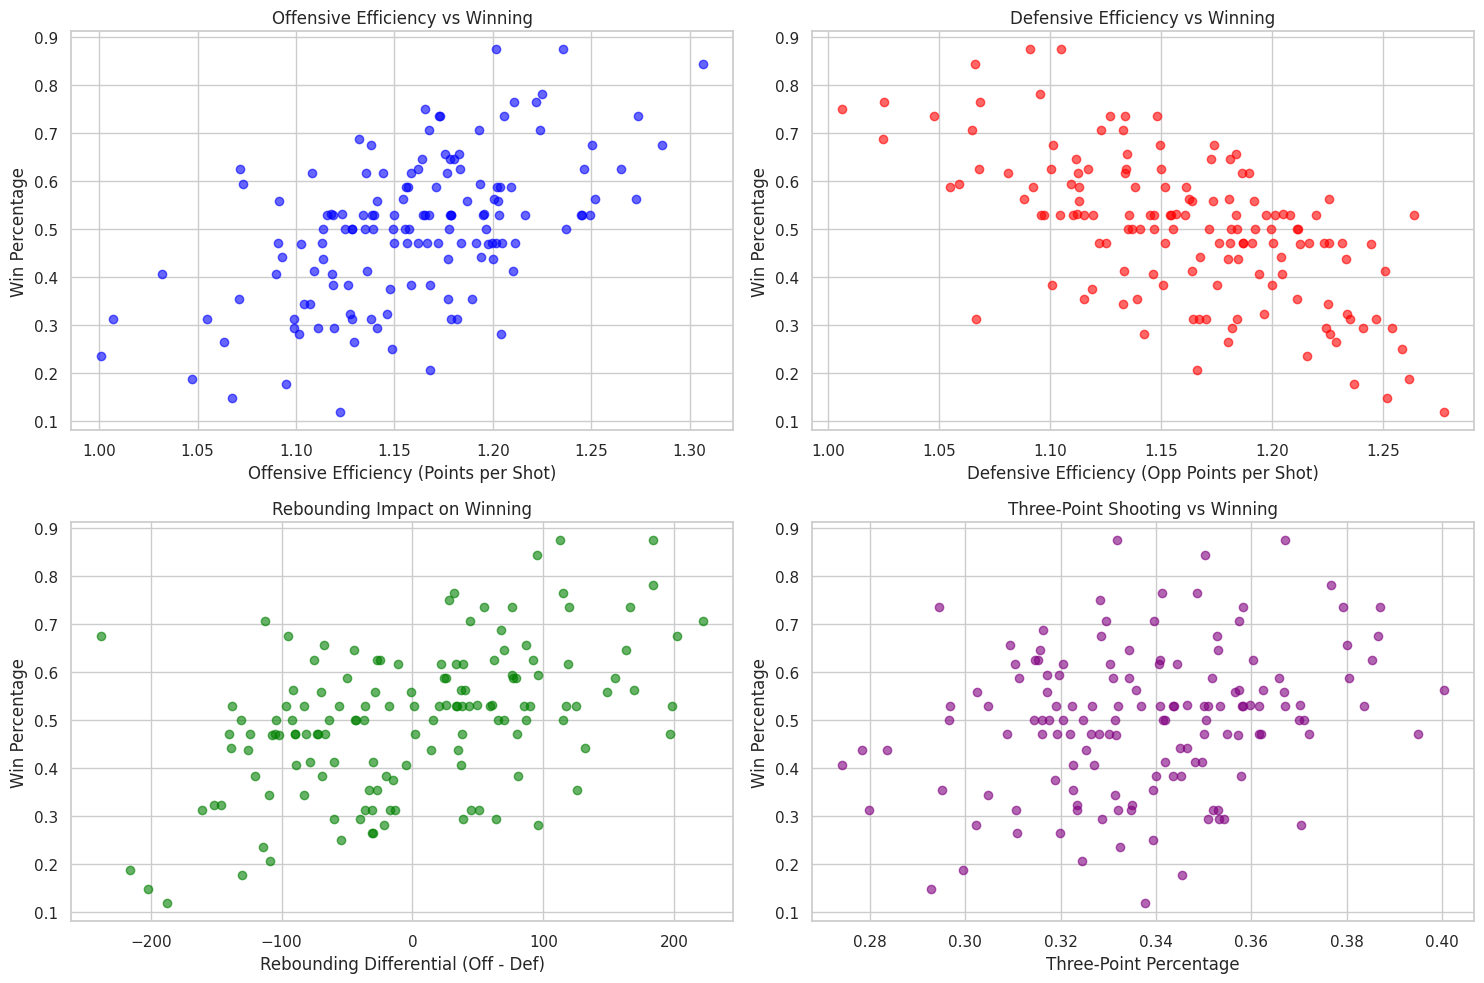

In [86]:
# Efficiency analysis visualizations
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Offensive efficiency vs win percentage
axes[0, 0].scatter(teams_copy['off_efficiency'], teams_copy['win_pct'], alpha=0.6, color='blue')
axes[0, 0].set_xlabel('Offensive Efficiency (Points per Shot)')
axes[0, 0].set_ylabel('Win Percentage')
axes[0, 0].set_title('Offensive Efficiency vs Winning')

# Defensive efficiency vs win percentage
axes[0, 1].scatter(teams_copy['def_efficiency'], teams_copy['win_pct'], alpha=0.6, color='red')
axes[0, 1].set_xlabel('Defensive Efficiency (Opp Points per Shot)')
axes[0, 1].set_ylabel('Win Percentage')
axes[0, 1].set_title('Defensive Efficiency vs Winning')

# Rebounding analysis
axes[1, 0].scatter(teams_copy['reb_diff'], teams_copy['win_pct'], alpha=0.6, color='green')
axes[1, 0].set_xlabel('Rebounding Differential (Off - Def)')
axes[1, 0].set_ylabel('Win Percentage')
axes[1, 0].set_title('Rebounding Impact on Winning')

# Three-point shooting analysis
axes[1, 1].scatter(teams_copy['three_pct'], teams_copy['win_pct'], alpha=0.6, color='purple')
axes[1, 1].set_xlabel('Three-Point Percentage')
axes[1, 1].set_ylabel('Win Percentage')
axes[1, 1].set_title('Three-Point Shooting vs Winning')

plt.tight_layout()
plt.show()

**Efficiency Insights:**
- **Offensive Efficiency:** Teams that score more points per shot win more
- **Defensive Efficiency:** Teams that concede more points per shot win less
- **Rebounding:** Strong positive correlation with winning - teams dominating boards win more
- **Three-Point Shooting:** Moderate positive correlation - less deterministic than rebounding

#### Conference Performance Comparison

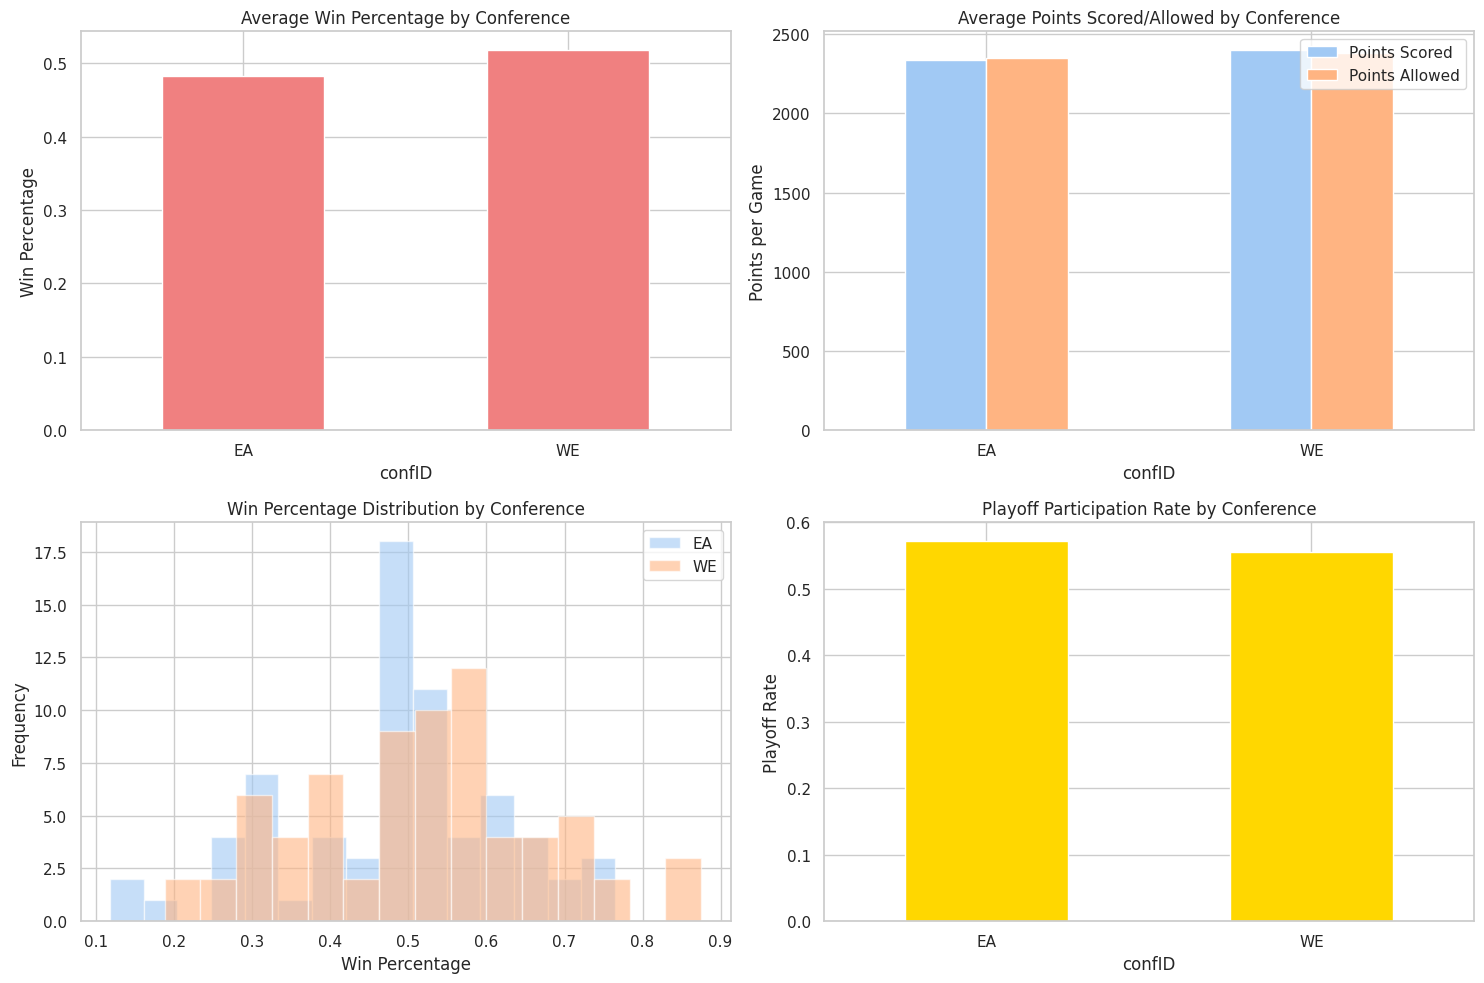

Conference performance summary:
         win_pct        o_pts        d_pts  team_seasons
confID                                                  
EA      0.481985  2334.171429  2350.885714            70
WE      0.517514  2397.486111  2381.208333            72


In [87]:
# Conference performance comparison
conference_performance = teams_copy.groupby('confID').agg({
    'win_pct': 'mean',
    'o_pts': 'mean',
    'd_pts': 'mean',
    'year': 'count'
}).rename(columns={'year': 'team_seasons'})

conference_performance = conference_performance[conference_performance['team_seasons'] > 10]

fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Conference win percentages
conference_performance['win_pct'].plot(kind='bar', ax=axes[0, 0], color='lightcoral')
axes[0, 0].set_title('Average Win Percentage by Conference')
axes[0, 0].set_ylabel('Win Percentage')
axes[0, 0].tick_params(axis='x', rotation=0)

# Conference scoring
conference_performance[['o_pts', 'd_pts']].plot(kind='bar', ax=axes[0, 1])
axes[0, 1].set_title('Average Points Scored/Allowed by Conference')
axes[0, 1].set_ylabel('Points per Game')
axes[0, 1].tick_params(axis='x', rotation=0)
axes[0, 1].legend(['Points Scored', 'Points Allowed'])

# Competitive balance
for i, conf in enumerate(teams_copy['confID'].unique()):
    if pd.notna(conf) and conf != '':
        conf_data = teams_copy[teams_copy['confID'] == conf]['win_pct']
        if len(conf_data) > 5:
            axes[1, 0].hist(conf_data, alpha=0.6, label=conf, bins=15)

axes[1, 0].set_title('Win Percentage Distribution by Conference')
axes[1, 0].set_xlabel('Win Percentage')
axes[1, 0].set_ylabel('Frequency')
axes[1, 0].legend()

# Playoff success by conference
conference_playoffs = teams_copy[teams_copy['playoff'] == 'Y'].groupby('confID').size()
conference_total = teams_copy.groupby('confID').size()
playoff_rate = (conference_playoffs / conference_total).dropna()

playoff_rate.plot(kind='bar', ax=axes[1, 1], color='gold')
axes[1, 1].set_title('Playoff Participation Rate by Conference')
axes[1, 1].set_ylabel('Playoff Rate')
axes[1, 1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

print("Conference performance summary:")
print(conference_performance)

**Insight**: Apart from the win percentage being more evenly distributed in the western conference, there are no significant differences in the performance of teams from both conferences.

#### Home Court Advantage Analysis

In [88]:
# Calculate home court advantage
teams_copy['home_win_pct'] = teams_copy['homeW'] / (teams_copy['homeW'] + teams_copy['homeL'])
teams_copy['away_win_pct'] = teams_copy['awayW'] / (teams_copy['awayW'] + teams_copy['awayL'])
teams_copy['home_advantage'] = teams_copy['home_win_pct'] - teams_copy['away_win_pct']

print(f"League average home court advantage: {teams_copy['home_advantage'].mean():.3f}")
print(f"Home win percentage: {teams_copy['home_win_pct'].mean():.3f}")
print(f"Away win percentage: {teams_copy['away_win_pct'].mean():.3f}")

League average home court advantage: 0.220
Home win percentage: 0.610
Away win percentage: 0.390


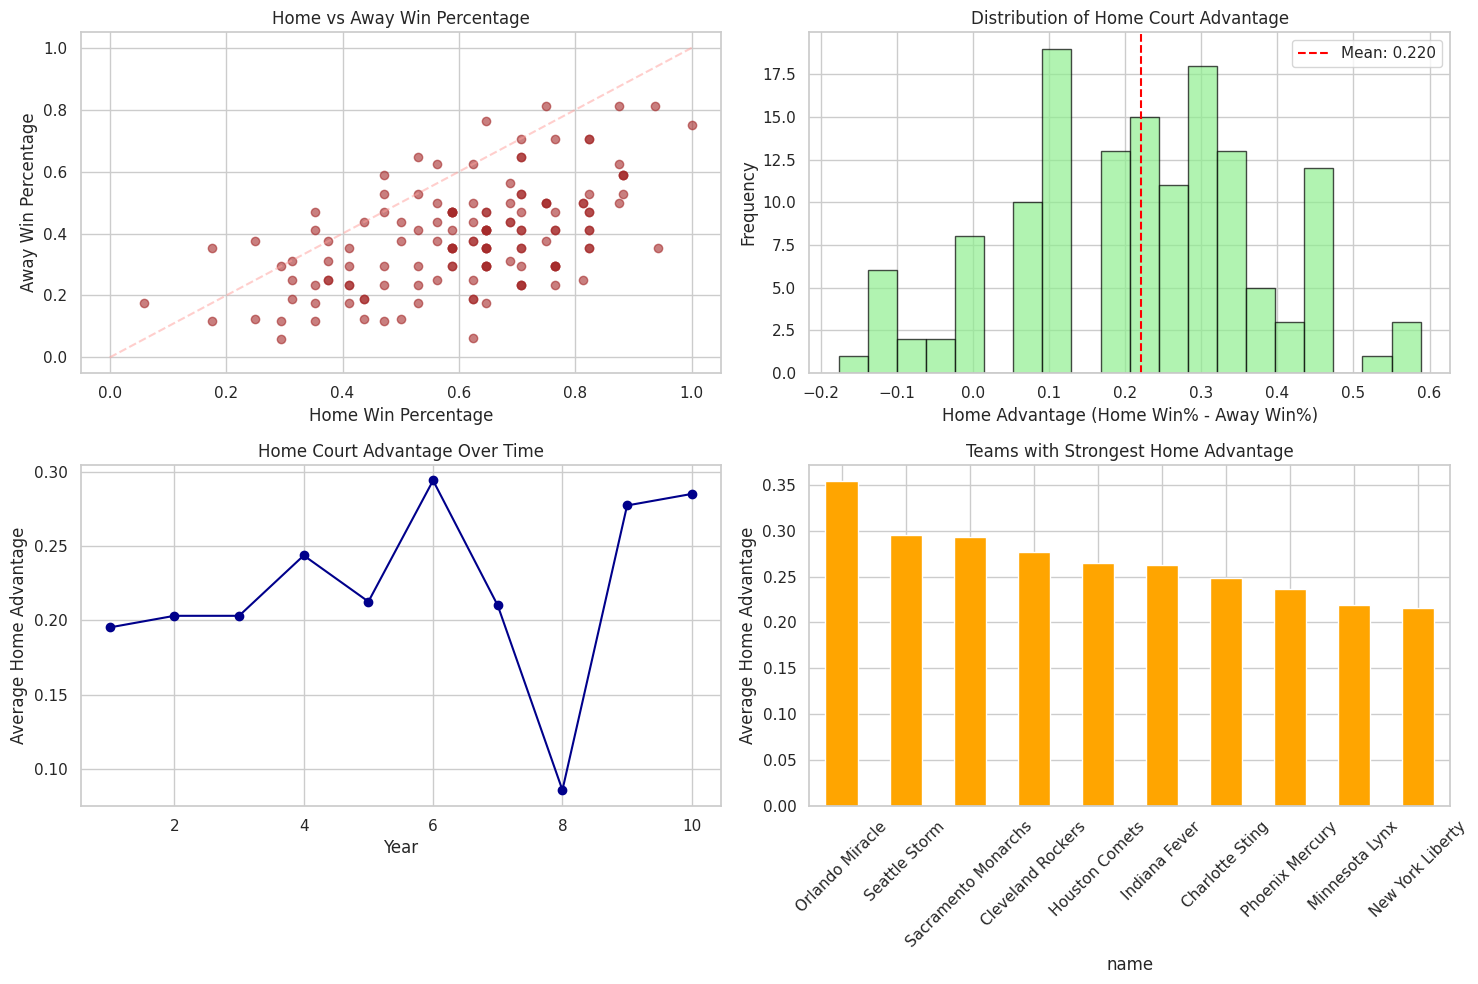

In [89]:
# Home court advantage visualizations
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Home vs Away win percentage
axes[0, 0].scatter(teams_copy['home_win_pct'], teams_copy['away_win_pct'], alpha=0.6, color='brown')
axes[0, 0].plot([0, 1], [0, 1], 'r--', alpha=0.5)
axes[0, 0].set_xlabel('Home Win Percentage')
axes[0, 0].set_ylabel('Away Win Percentage')
axes[0, 0].set_title('Home vs Away Win Percentage')

# Home advantage distribution
axes[0, 1].hist(teams_copy['home_advantage'], bins=20, alpha=0.7, color='lightgreen', edgecolor='black')
axes[0, 1].axvline(teams_copy['home_advantage'].mean(), color='red', linestyle='--',
                   label=f'Mean: {teams_copy["home_advantage"].mean():.3f}')
axes[0, 1].set_xlabel('Home Advantage (Home Win% - Away Win%)')
axes[0, 1].set_ylabel('Frequency')
axes[0, 1].set_title('Distribution of Home Court Advantage')
axes[0, 1].legend()

# Home advantage over time
home_adv_by_year = teams_copy.groupby('year')['home_advantage'].mean()
axes[1, 0].plot(home_adv_by_year.index, home_adv_by_year.values, marker='o', color='darkblue')
axes[1, 0].set_xlabel('Year')
axes[1, 0].set_ylabel('Average Home Advantage')
axes[1, 0].set_title('Home Court Advantage Over Time')

# Teams with strongest home advantage
top_home_teams = teams_copy.groupby('name')['home_advantage'].mean().sort_values(ascending=False)
top_home_teams.head(10).plot(kind='bar', ax=axes[1, 1], color='orange')
axes[1, 1].set_title('Teams with Strongest Home Advantage')
axes[1, 1].set_ylabel('Average Home Advantage')
axes[1, 1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

**Home Court Advantage Insights:**
- Home court advantage is normally distributed around mean of 0.220 (22% difference)
- Most teams cluster between 0.1 and 0.3 advantage
- Teams that win generally do so independently of location, but still perform better at home
- A few outliers show negative home court advantage or exceptionally strong advantages

#### Team Ranking Correlation

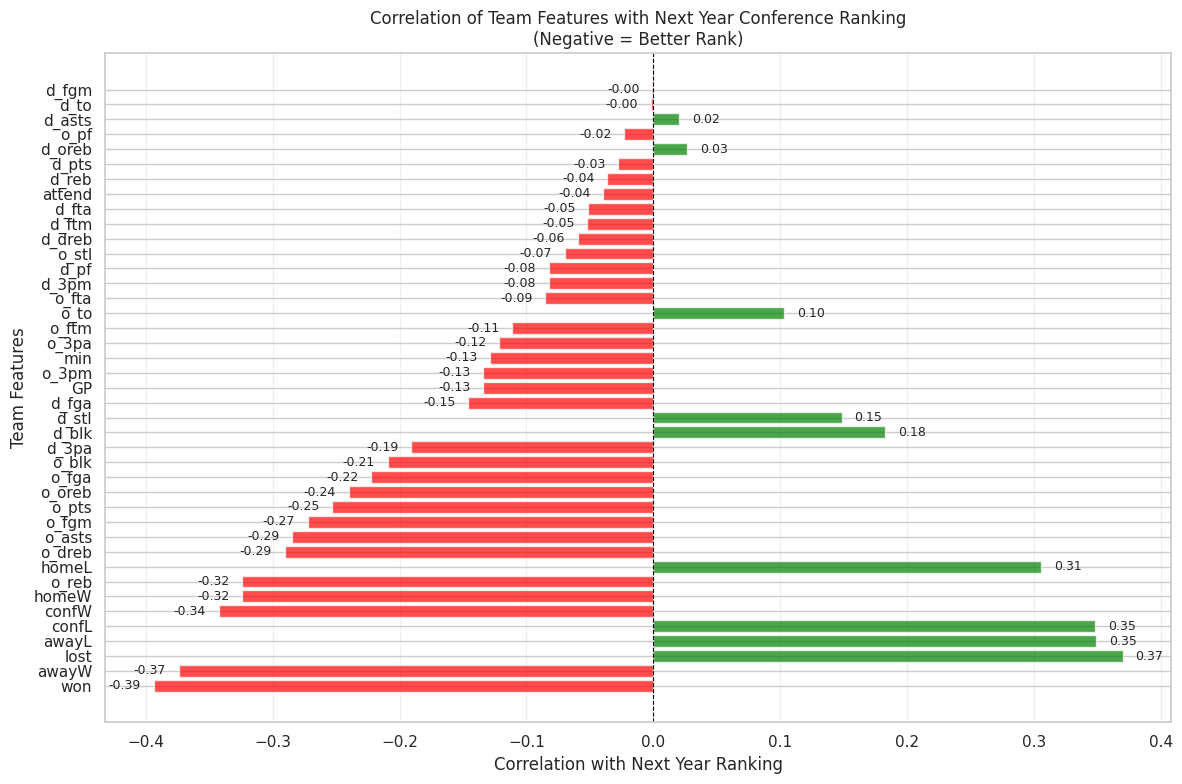

In [90]:
teams_ranking = teams_df.copy()

teams_ranking = teams_ranking.sort_values(['tmID', 'year'])

# Create next year's rank column
teams_ranking['next_year_rank'] = teams_ranking.groupby('tmID')['rank'].shift(-1)

# Remove rows where we don't have next year's rank
teams_ranking_clean = teams_ranking.dropna(subset=['next_year_rank'])

cols_to_exclude = [
    'year', 'rank', 'next_year_rank', 'seeded', 
    'tmORB', 'tmDRB', 'tmTRB', 'opptmORB', 'opptmDRB', 'opptmTRB', 
    'divID', 'lgID', 'firstRound', 'semis', 'finals'
]

feature_cols = [
    col for col in teams_ranking_clean.select_dtypes(include='number').columns
    if col not in cols_to_exclude
]
correlations = teams_ranking_clean[feature_cols + ['next_year_rank']].corr()['next_year_rank'].drop('next_year_rank')

correlations_sorted = correlations.reindex(correlations.abs().sort_values(ascending=False).index)

plt.figure(figsize=(12, 8))
colors = ['red' if x < 0 else 'green' for x in correlations_sorted.values]
plt.barh(range(len(correlations_sorted)), correlations_sorted.values, color=colors, alpha=0.7)
plt.yticks(range(len(correlations_sorted)), correlations_sorted.index)
plt.xlabel('Correlation with Next Year Ranking')
plt.ylabel('Team Features')
plt.title('Correlation of Team Features with Next Year Conference Ranking\n(Negative = Better Rank)')
plt.axvline(x=0, color='black', linestyle='--', linewidth=0.8)
plt.grid(axis='x', alpha=0.3)

for i, v in enumerate(correlations_sorted.values):
    plt.text(v + (0.01 if v > 0 else -0.01), i, f'{v:.2f}',
             va='center', ha='left' if v > 0 else 'right', fontsize=9)

plt.tight_layout()
plt.show()

**Insights**:

- The number of wins and losses are generally the strongest predictors of future team ranking.

- Offensive statistics have more predictive power overall compared to defensive metrics.